# DeepLearning Wafer Defect Analysis


## Automated Surface Inspection in Electronics Manufacturing

The semiconductor industry relies on precise quality assurance mechanisms to identify surface irregularities on silicon substrates. Historically, technicians performed visual examinations or employed basic scanning protocols, both of which proved labor-intensive and prone to inconsistency. Modern deep neural networks offer a computational pathway to automate anomaly identification from substrate imagery, dramatically enhancing both detection sensitivity and throughput.

### Library Dependencies

In [22]:
# Essential libraries for numerical computations and data handling
import numpy as np
import pandas as pd
import pickle
import sklearn
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib.gridspec as mg
import cv2
import gc

# Set visualization themes distinctly
plt.style.use('fivethirtyeight')
sb.set_context('notebook', font_scale=1.2)
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Deep learning with PyTorch toolkit
# import torch
# import torchvision
# import torch.nn as nn
# import torch.nn.functional as F
# import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split, SubsetRandomSampler, ConcatDataset
from PIL import Image

from tensorflow.keras.layers import InputLayer, Conv2D, Dense, MaxPooling2D
from tensorflow.keras.layers import Flatten, Softmax, SpatialDropout2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam


# Image augmentation utilities
import imgaug as ia
import imgaug.augmenters as iaa

# Duplicate matplotlib import removed intentionally, keeping only necessary
# %matplotlib inline is already declared above

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


import warnings
warnings.filterwarnings("ignore", message=".*FixedFormatter.*", category=UserWarning)

## Dataset Overview: Silicon Substrate Inspection Records

### Dataset Overview: Silicon Substrate Inspection Records

The LSWMD (Large-Scale Wafer-Map Dataset) dataset aggregates over 800,000 substrate inspection maps collected from tens of thousands of semiconductor fabrication batches. Each map functions as a spatial heatmap depicting failure locations across a circular silicon wafer surface. This collection serves as a benchmark resource for researchers developing pattern recognition and automated inspection systems.

Dataset Statistics
Volume and Scope:

- Total substrate maps: ~811,457 records

- Manufacturing batches: 46,393 distinct lots

- Real-world conditions: Multiple fabrication facilities

Primary Applications:

- Supervised classification of surface anomalies

- Benchmark development for anomaly detection algorithms

- Manufacturing process analytics

*Categorized Anomaly Patterns*

The dataset distinguishes eight distinct surface defect morphologies, each representing unique manufacturing or environmental causes:

- Center-Concentrated: Defects cluster in the wafer's central region

- Annular: Ring-shaped fault pattern with clear center regions

- Perimeter-Localized: Faults isolated to edge zones

- Edge-Band: Continuous ring of defects around perimeter

- Discrete-Zone: Isolated fault clusters in specific locations

- Scattered: Randomly distributed defects without spatial coherence

- Linear-Trace: Directional damage patterns from mechanical interaction

- Near-Complete: Extensive failure across most substrate surface

Access: [Kaggle](https://www.kaggle.com/datasets/qingyi/wm811k-wafer-map).

## Data Import, Data Schema

Column Name	Data Type	Description
substrateImage	object	Raster representation of surface scan result
unitScale	float64	Physical dimension of individual circuit units batchIdentifier	object	Alphanumeric lot designation substrateSequence	float64	Ordinal position within production batch dataPartition	object	Training/validation split assignment anomalyClass	object	Categorical anomaly type identifier.

Key observations:

- Approximately 172,950 substrates carry classification labels (~21.3% of total)

- Only ~25,519 substrates (3.1% of labeled) exhibit actual fault patterns

- 147,431 labeled substrates show no detectable anomalies

- This severe class imbalance necessitates careful sampling strategies during model training



In [23]:
df = pd.read_pickle('/content/LSWMD.pkl.zip')

In [24]:
primary_df = df.copy()
primary_df.info()
primary_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


### Extract Image Dimensions

In [25]:
# Calculate pixel dimensions for each substrate scan
def extract_dimensions(image_array):
    rows = np.size(image_array, axis=0)
    cols = np.size(image_array, axis=1)
    return (rows, cols)

# Use the correct column name 'waferMap' from the loaded data
primary_df['pixel_dimensions'] = primary_df.waferMap.apply(extract_dimensions)
print(f"Sample dimension inspection:\n{primary_df[['pixel_dimensions']].head()}")

# Identify unique aspect ratios
unique_dimensions = np.unique(primary_df['pixel_dimensions'])
print(f"Unique dimension specifications: {len(unique_dimensions)}")


Sample dimension inspection:
  pixel_dimensions
0         (45, 48)
1         (45, 48)
2         (45, 48)
3         (45, 48)
4         (45, 48)
Unique dimension specifications: 632


### Label Encoding Pipeline

In [26]:
# Extraction function
def extract_value(x):
    """Recursively extract the actual value from nested lists/arrays, handling edge cases"""
    if x is None:
        return None

    while isinstance(x, (list, np.ndarray)):
        if len(x) == 0:
            return None
        x = x[0]

    return x

primary_df['failureType_clean'] = primary_df.failureType.apply(extract_value)
primary_df['trianTestLabel_clean'] = primary_df.trianTestLabel.apply(extract_value)

# Verify cleaning worked
print("Sample cleaned values:")
print(primary_df[['failureType', 'failureType_clean', 'trianTestLabel_clean']].head(10))

# Check for any None values
print(f"\nNone values in failureType_clean: {primary_df['failureType_clean'].isna().sum()}")
print(f"None values in trianTestLabel_clean: {primary_df['trianTestLabel_clean'].isna().sum()}")

# Define encodings
defect_encoding = {
    'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3,
    'Loc': 4, 'Random': 5, 'Scratch': 6, 'Near-full': 7, 'none': 8
}

partition_encoding = {'Training': 0, 'Test': 1}

# Use replace()
primary_df['defect_code'] = primary_df.failureType_clean.replace(defect_encoding)
primary_df['partition_code'] = primary_df.trianTestLabel_clean.replace(partition_encoding)

# Verify encoding
print("\nEncoded values:")
print(primary_df[['failureType_clean', 'defect_code', 'partition_code']].head(10))

Sample cleaned values:
  failureType failureType_clean trianTestLabel_clean
0    [[none]]              none             Training
1    [[none]]              none             Training
2    [[none]]              none             Training
3    [[none]]              none             Training
4    [[none]]              none             Training
5    [[none]]              none             Training
6    [[none]]              none             Training
7    [[none]]              none             Training
8    [[none]]              none             Training
9    [[none]]              none             Training

None values in failureType_clean: 638507
None values in trianTestLabel_clean: 638507

Encoded values:
  failureType_clean  defect_code  partition_code
0              none          8.0             0.0
1              none          8.0             0.0
2              none          8.0             0.0
3              none          8.0             0.0
4              none          8.0             0

/tmp/ipython-input-2870751399.py:34: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  primary_df['defect_code'] = primary_df.failureType_clean.replace(defect_encoding)
/tmp/ipython-input-2870751399.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  primary_df['partition_code'] = primary_df.trianTestLabel_clean.replace(partition_encoding)


### DataFrame Stratification

In [27]:
# Segment dataset by labeling status
df_all_labeled = primary_df[primary_df['defect_code'].notna() & (primary_df['defect_code'] >= 0) & (primary_df['defect_code'] <= 8)].reset_index(drop=True)
df_identified_faults = primary_df[primary_df['defect_code'].notna() & (primary_df['defect_code'] >= 0) & (primary_df['defect_code'] <= 7)].reset_index(drop=True)
df_null_class = primary_df[primary_df['defect_code'] == 8]

print(f"Substrates with any label: {len(df_all_labeled):,}")
print(f"Substrates with identified defects: {len(df_identified_faults):,}")
print(f"Substrates classified as fault-free: {len(df_null_class):,}")

Substrates with any label: 172,950
Substrates with identified defects: 25,519
Substrates classified as fault-free: 147,431


## Data Distribution Visualization

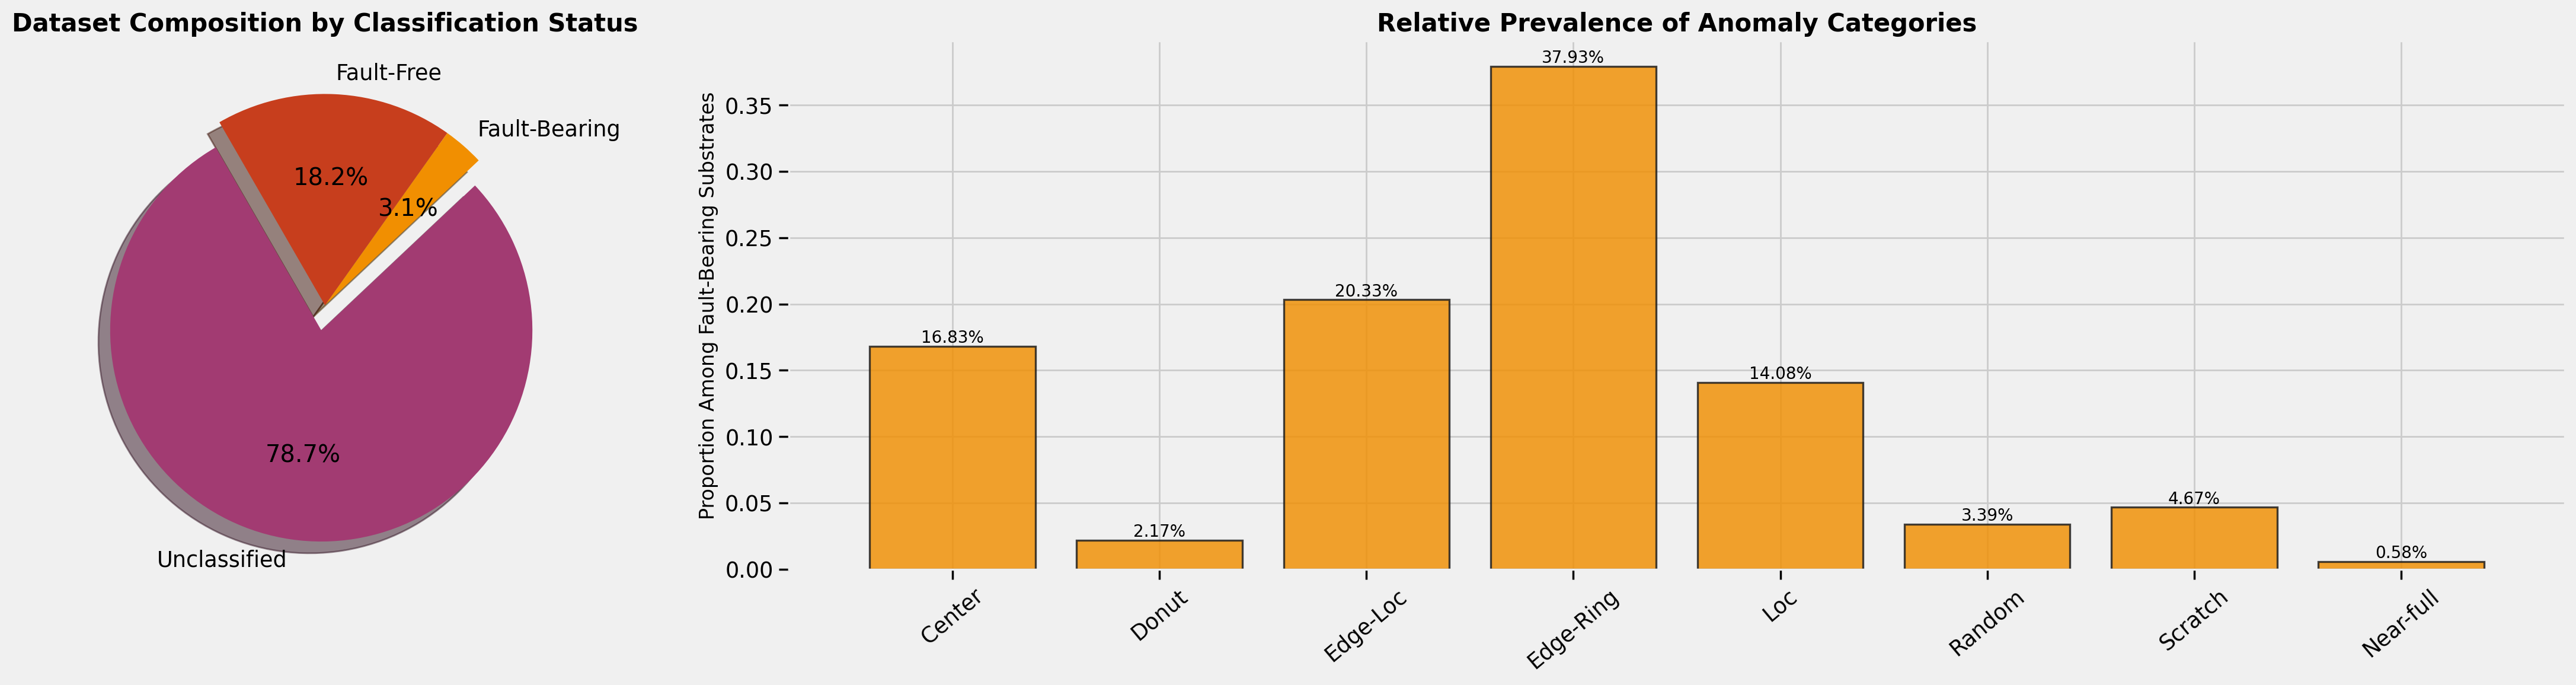

In [28]:
total_count = len(primary_df)

# Establish dual-panel figure layout
fig = plt.figure(figsize=(22, 6))
grid = mg.GridSpec(1, 2, width_ratios=[1, 2.8])  # Use mg instead of gs

# Left panel: Compositional breakdown
pie_axis = plt.subplot(grid[0])  # Fix: grid[0] instead of grid
composition = [total_count - len(df_all_labeled), len(df_identified_faults), len(df_null_class)]
palette = ['#A23B72', '#F18F01', '#C73E1D']
explosion = (0.12, 0, 0)
categories = ['Unclassified', 'Fault-Bearing', 'Fault-Free']

pie_axis.pie(composition, labels=categories, colors=palette, explode=explosion,
             autopct='%1.1f%%', shadow=True, startangle=120)
pie_axis.set_title('Dataset Composition by Classification Status', fontsize=15, weight='bold')

# Right panel: Frequency histogram by anomaly type
bar_axis = plt.subplot(grid[1])  # Fix: grid[1] instead of grid
defect_frequency = df_identified_faults['defect_code'].value_counts().sort_index()
sorted_indices = defect_frequency.index
normalized_frequency = defect_frequency.values / len(df_identified_faults)

anomaly_names = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Random', 'Scratch', 'Near-full']
sorted_names = [anomaly_names[int(i)] for i in sorted_indices]

bars_rect = bar_axis.bar(sorted_names, normalized_frequency, color='#F18F01', alpha=0.82, edgecolor='#1A1A1A', linewidth=1.2)
bar_axis.set_title('Relative Prevalence of Anomaly Categories', fontsize=15, weight='bold')
bar_axis.set_ylabel('Proportion Among Fault-Bearing Substrates', fontsize=12)
bar_axis.tick_params(axis='x', rotation=40)

# Add percentage labels on bars
for bar_elem in bars_rect:
    bar_height = bar_elem.get_height()
    bar_axis.text(bar_elem.get_x() + bar_elem.get_width() / 2, bar_height,
                  f'{bar_height:.2%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Visual Sample Gallery

### Representative Substrate Inspections

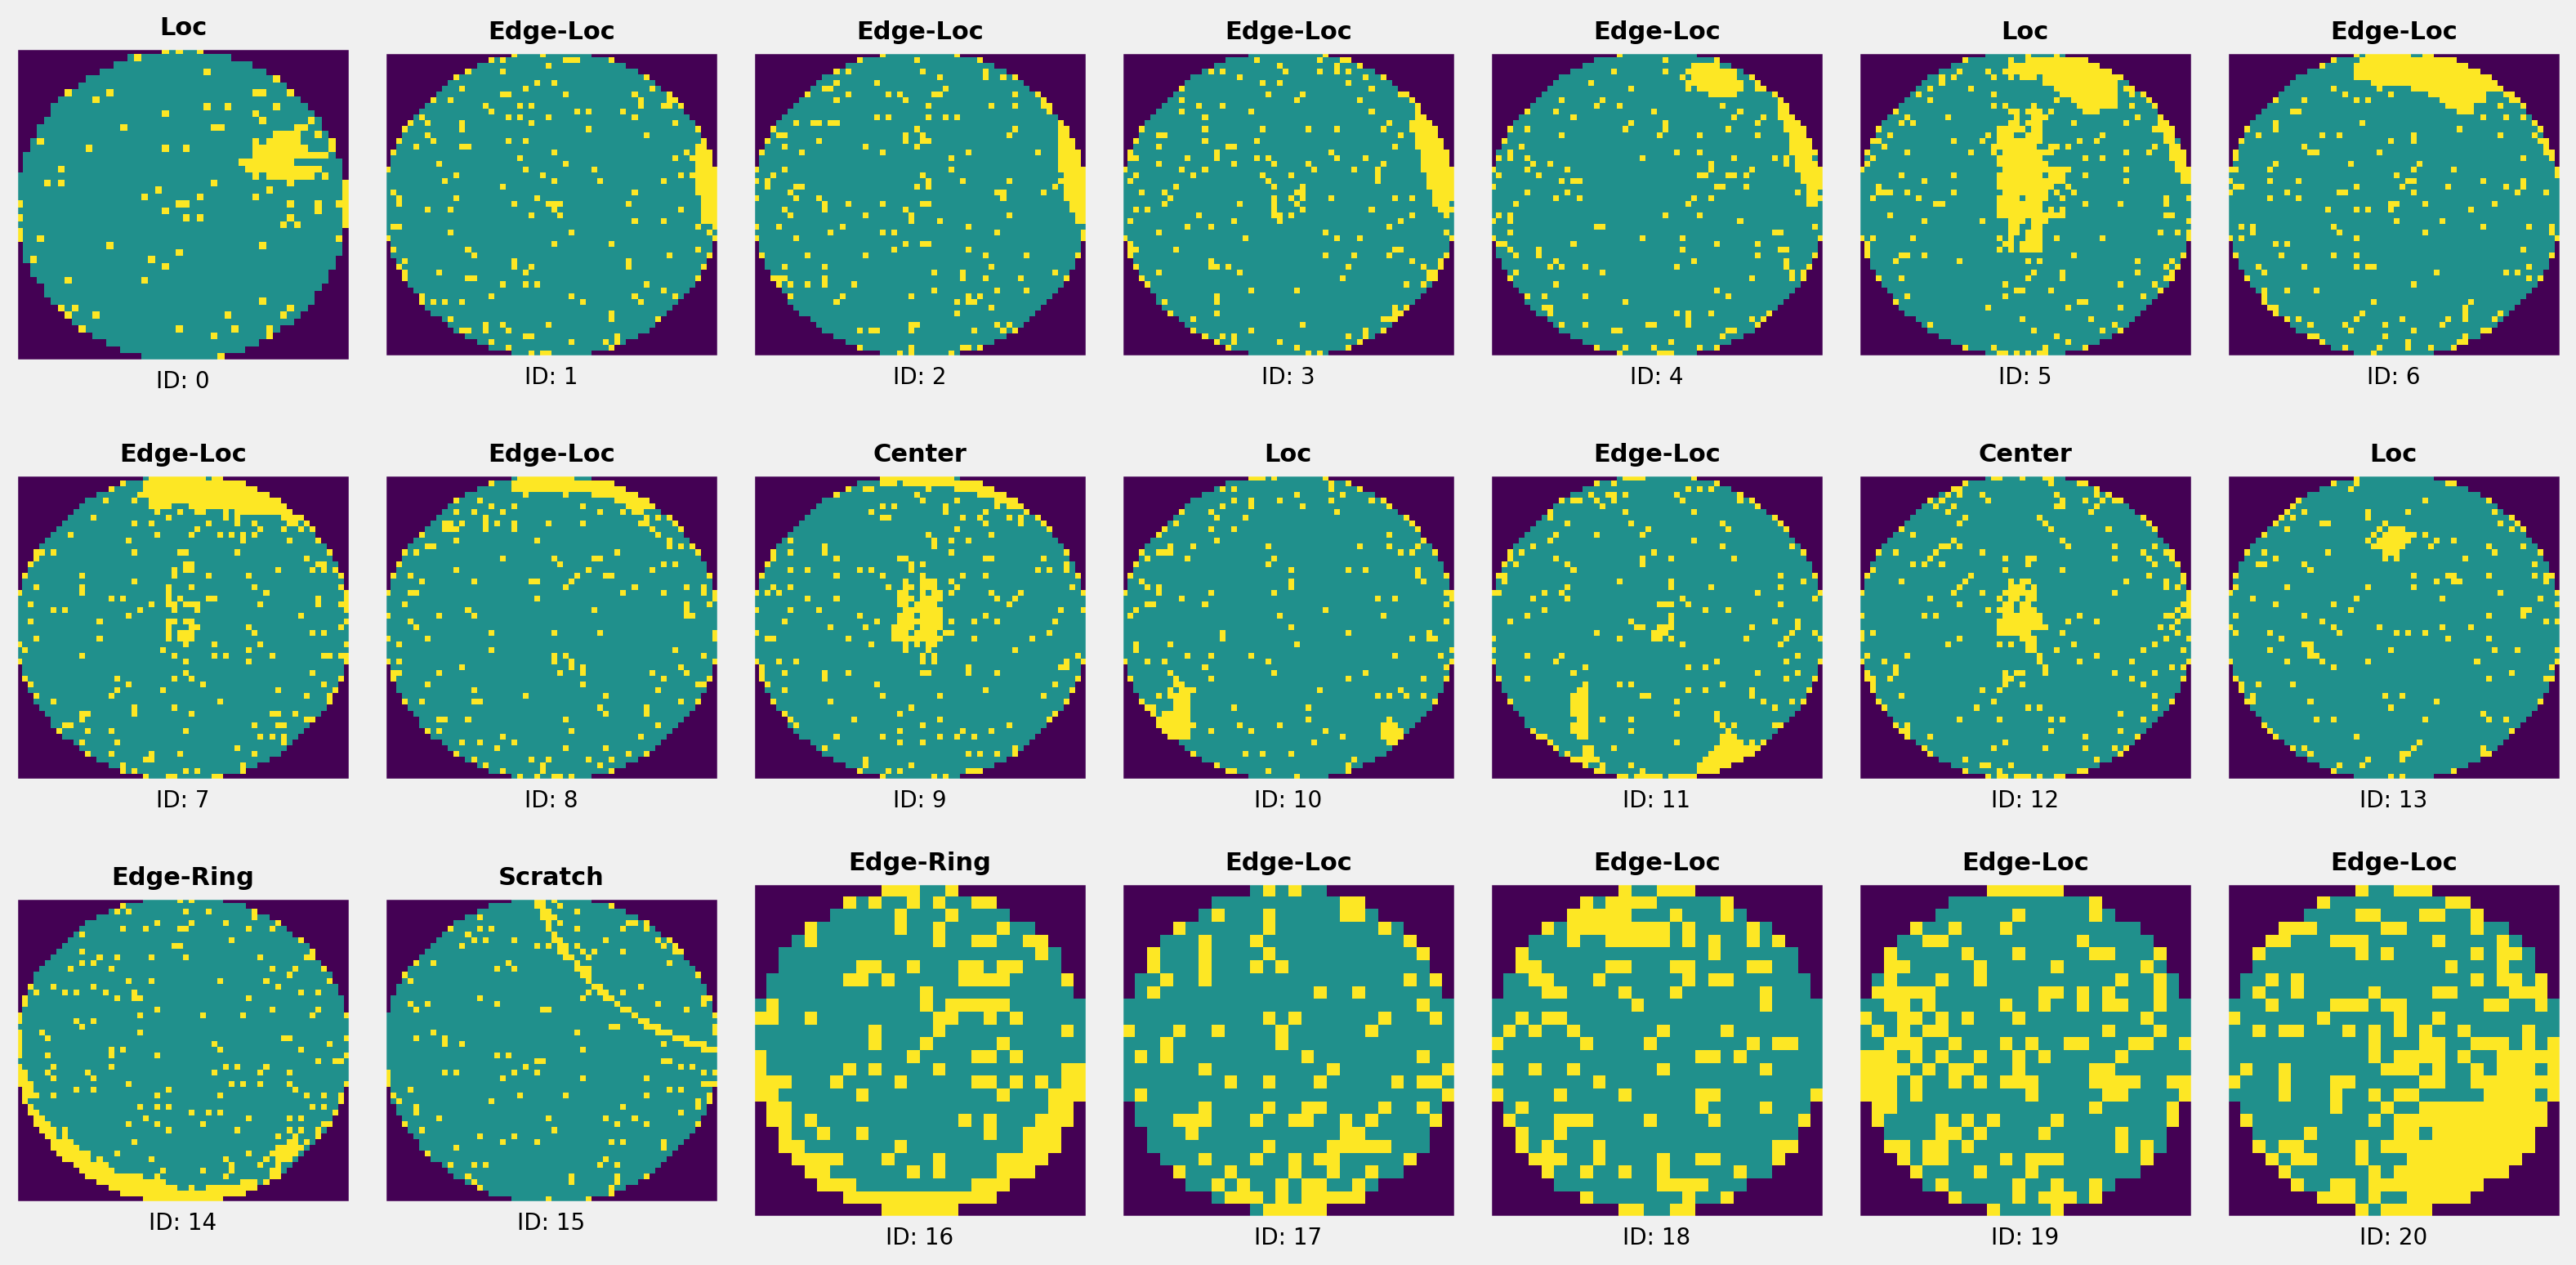

In [29]:
# Display 21 substrate samples in grid arrangement
fig, axes = plt.subplots(3, 7, figsize=(16, 8))
axes = axes.flatten()

for idx in range(21):
    substrate_img = df_identified_faults.waferMap[idx]  # CHANGE: waferMap not substrateImage
    axes[idx].imshow(substrate_img, cmap='viridis')
    axes[idx].set_title(df_identified_faults.failureType_clean[idx], fontsize=11, weight='semibold')  # CHANGE: failureType_clean
    axes[idx].set_xlabel(f'ID: {df_identified_faults.index[idx]}', fontsize=10)
    axes[idx].set_xticks([])
    axes[idx].set_yticks([])

plt.tight_layout()
plt.show()

### Category-Specific Inspection Samples

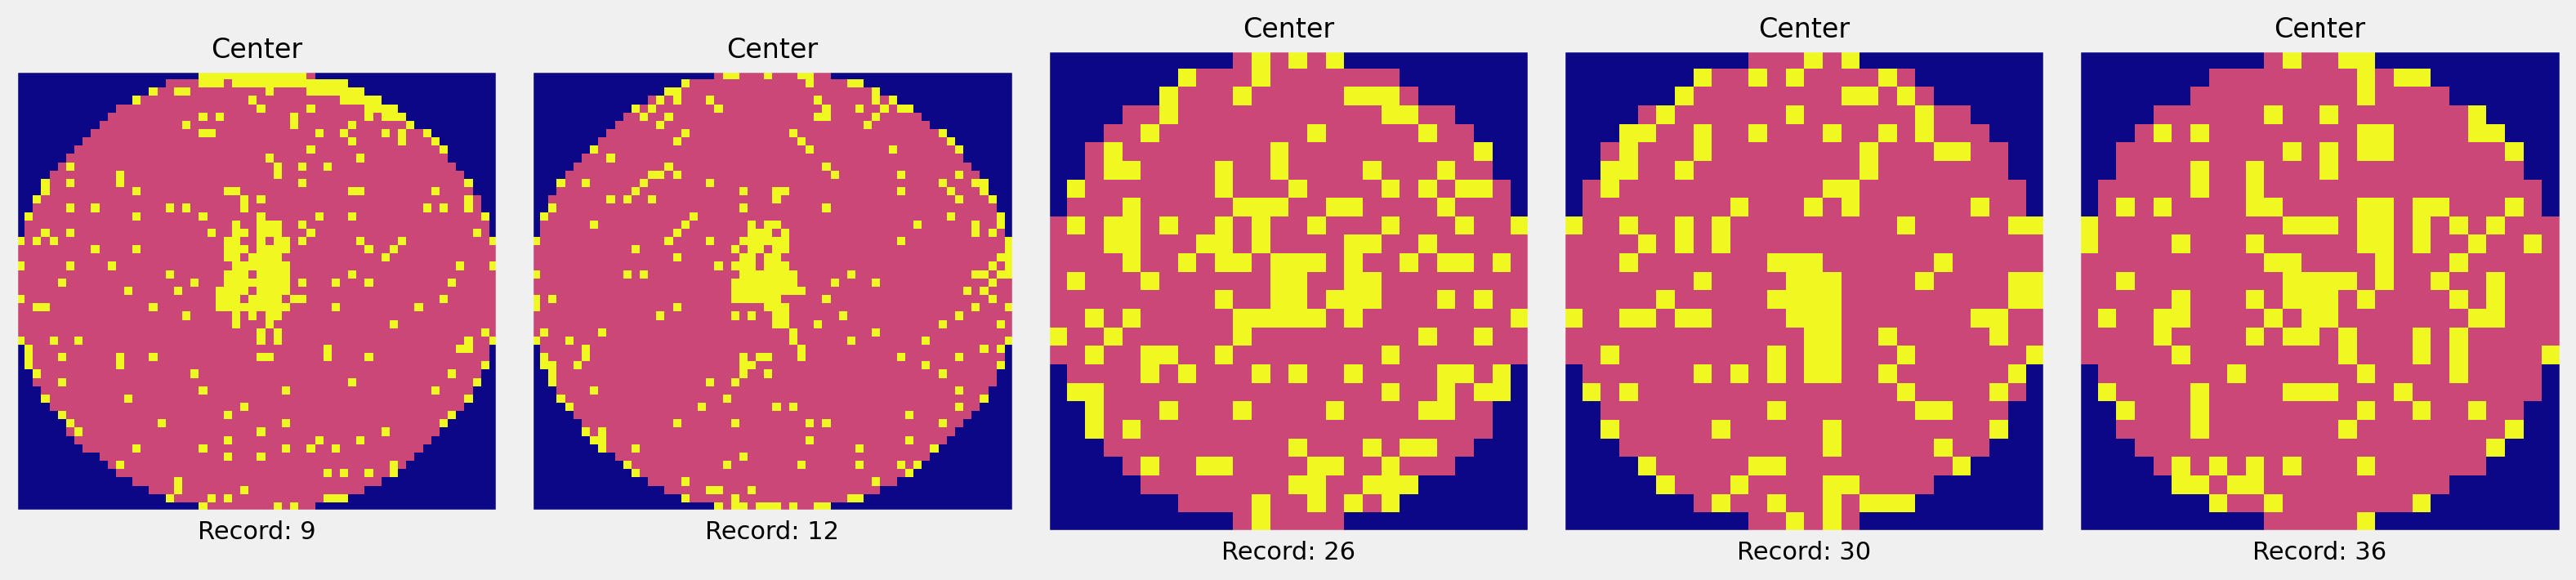

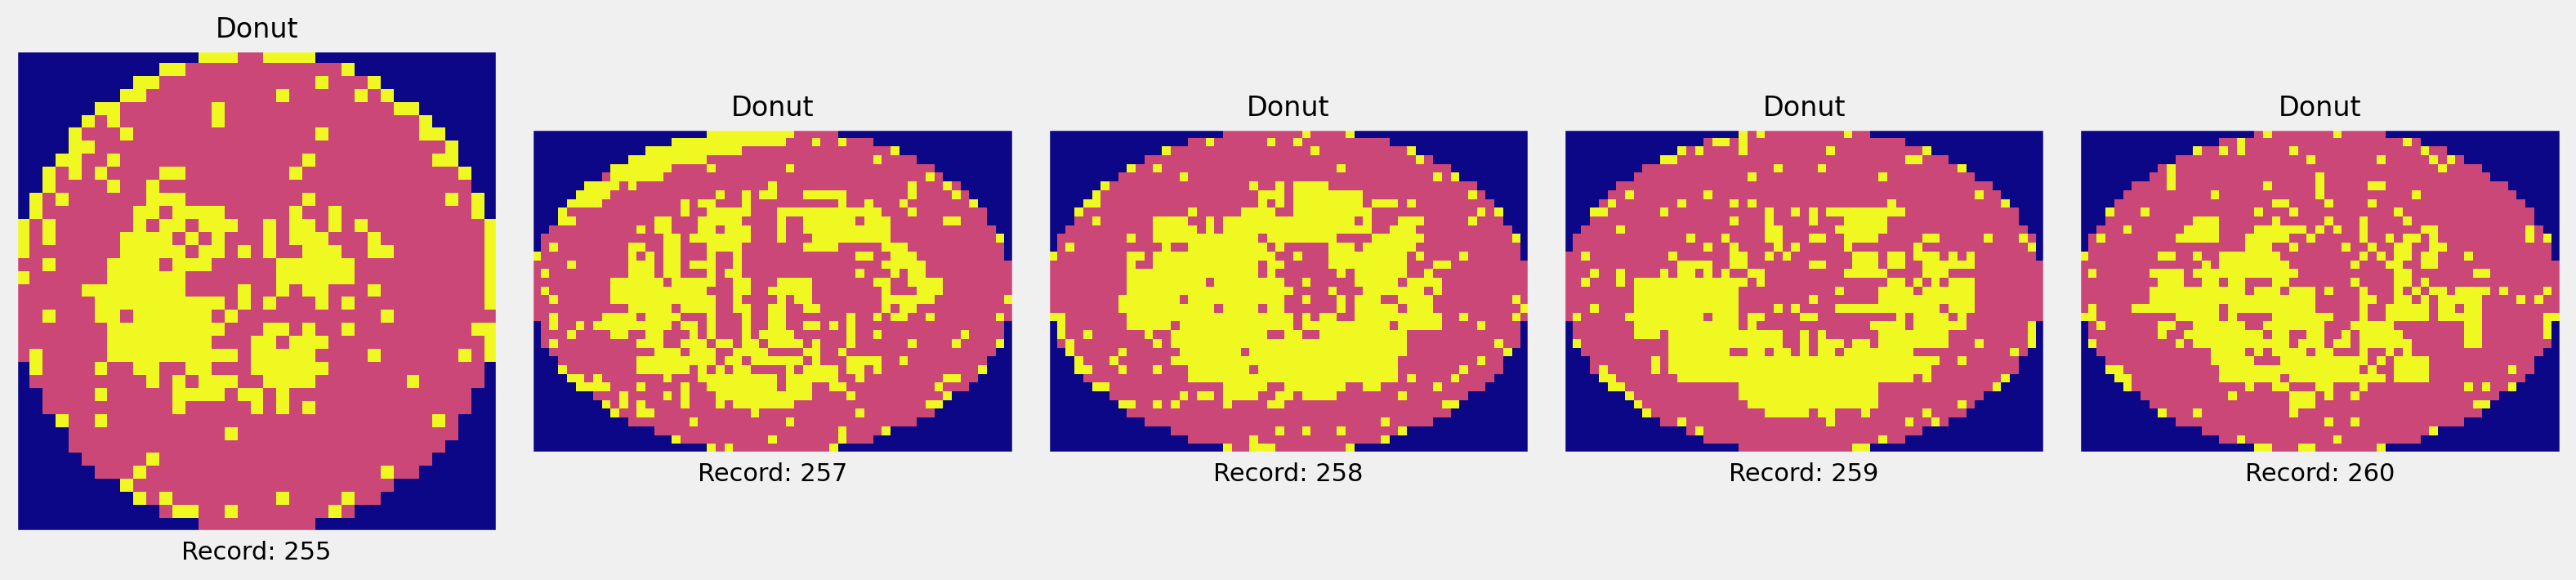

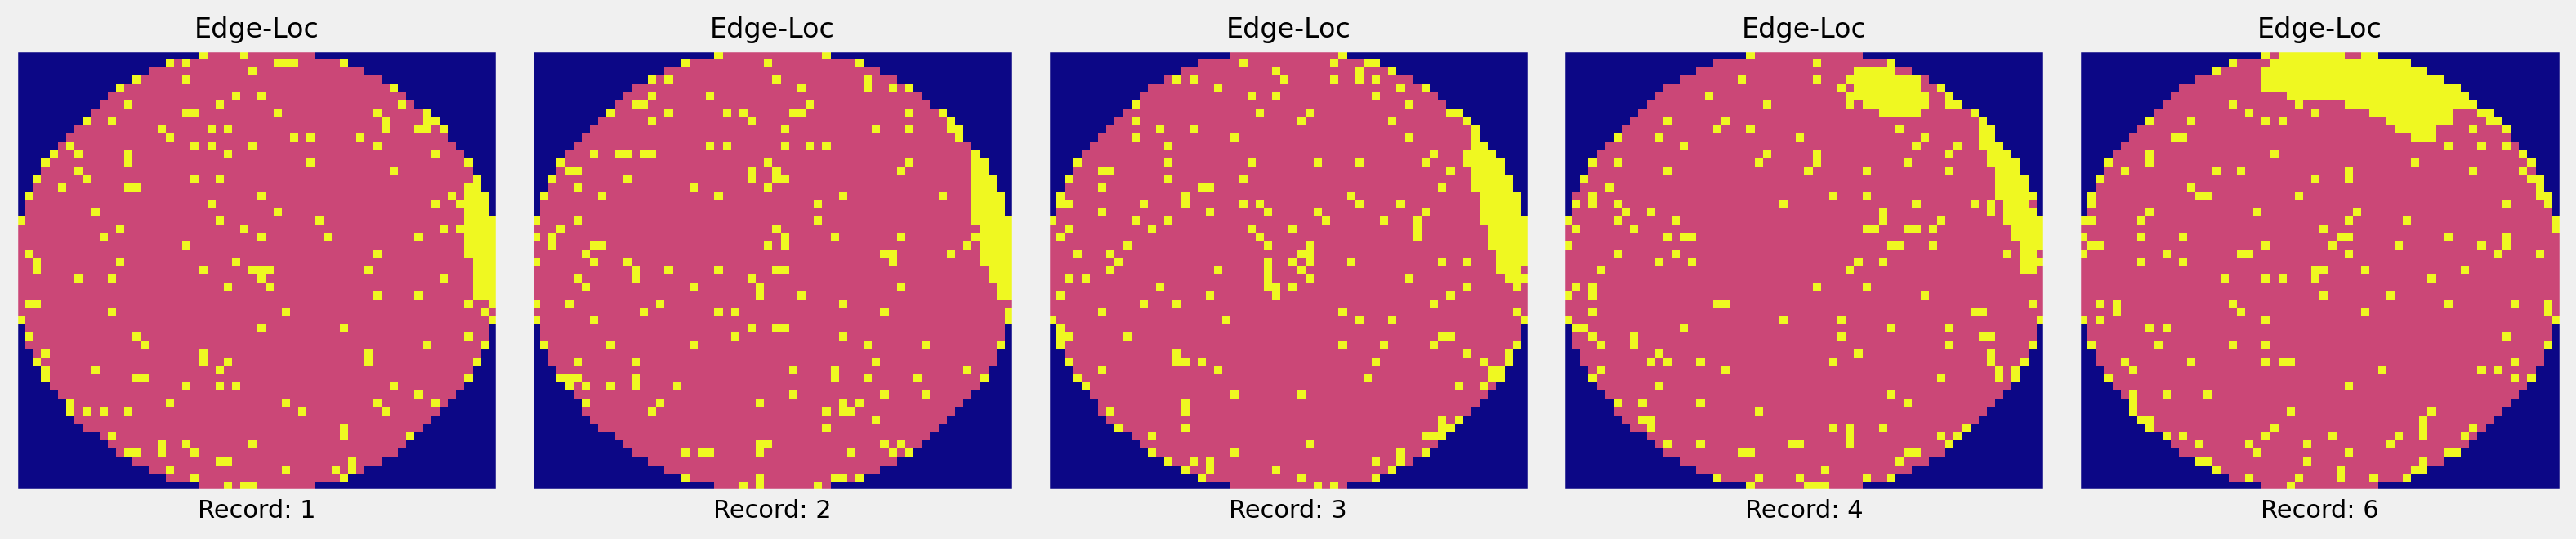

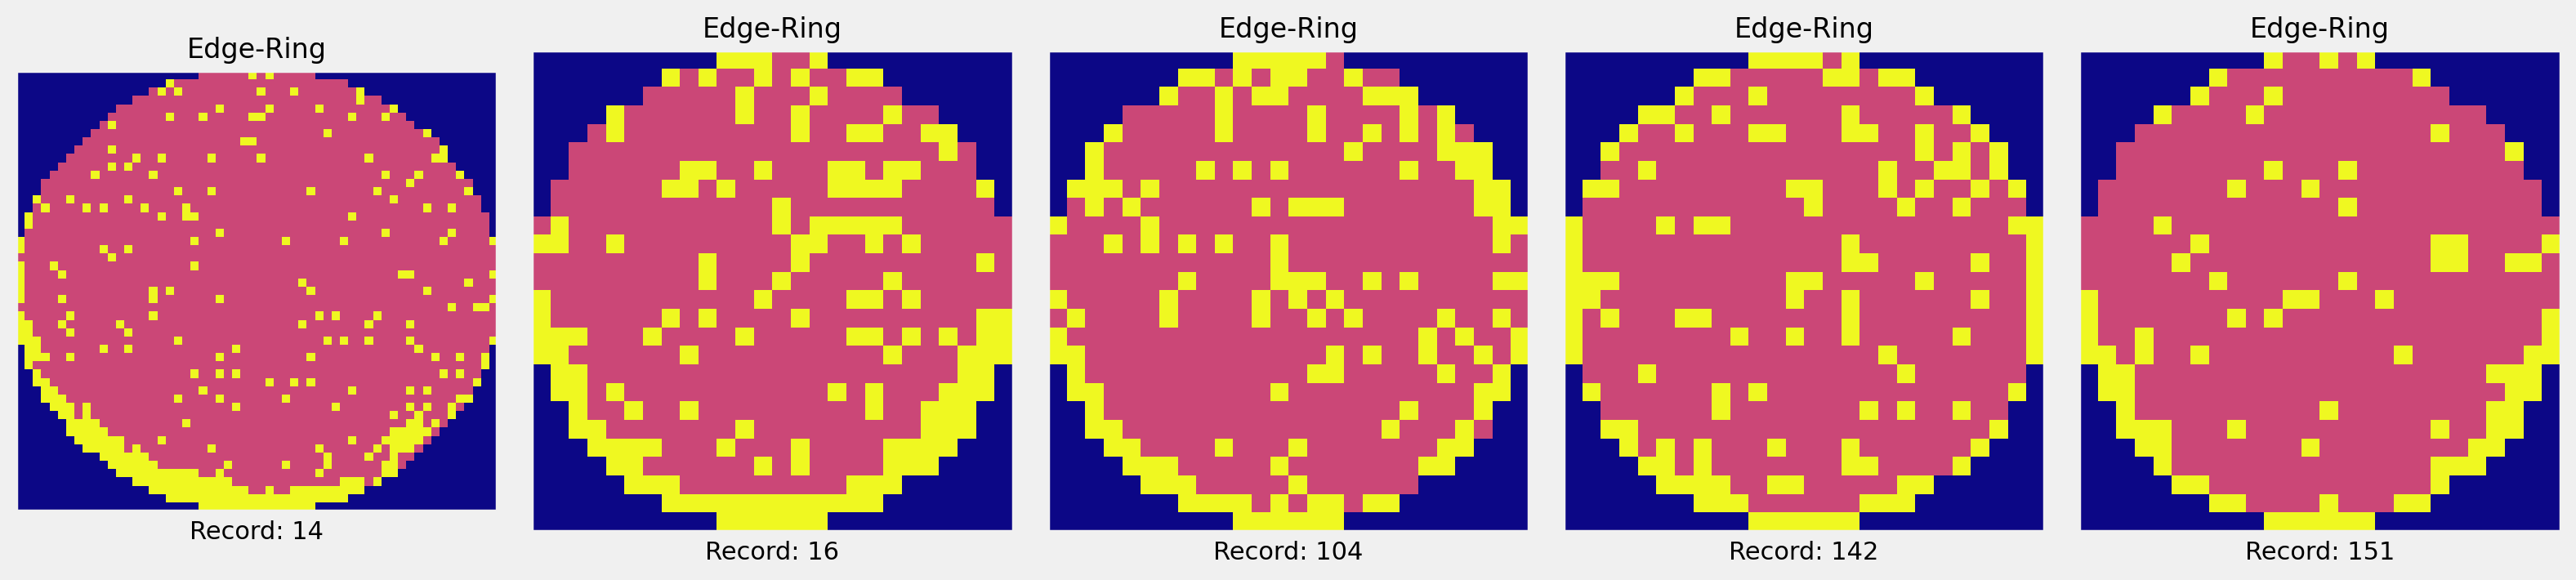

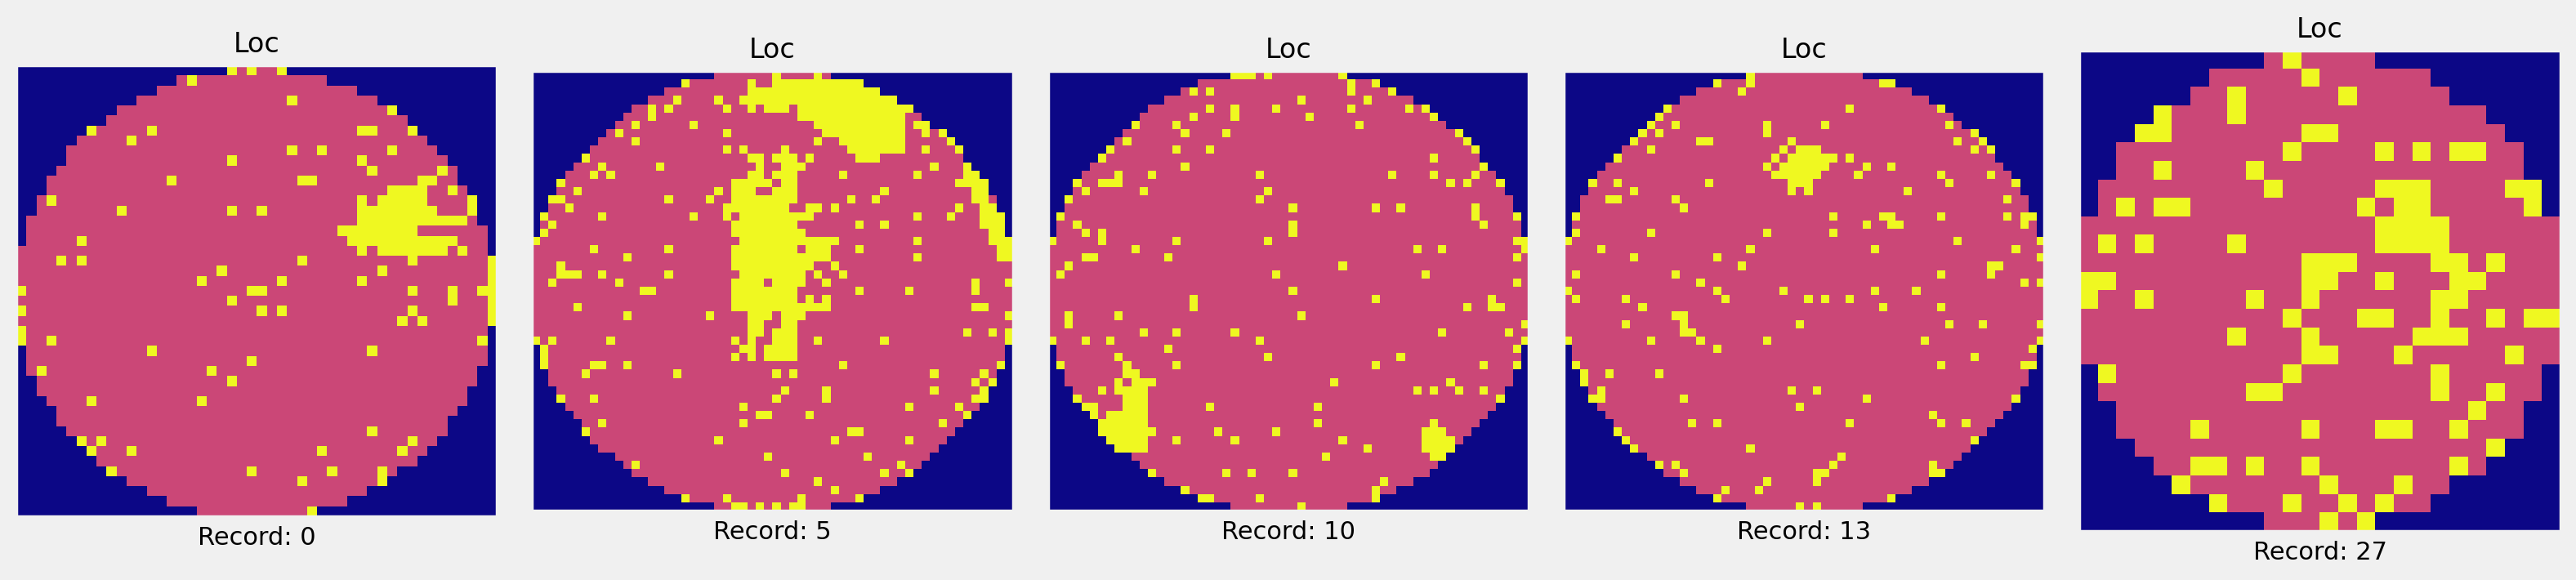

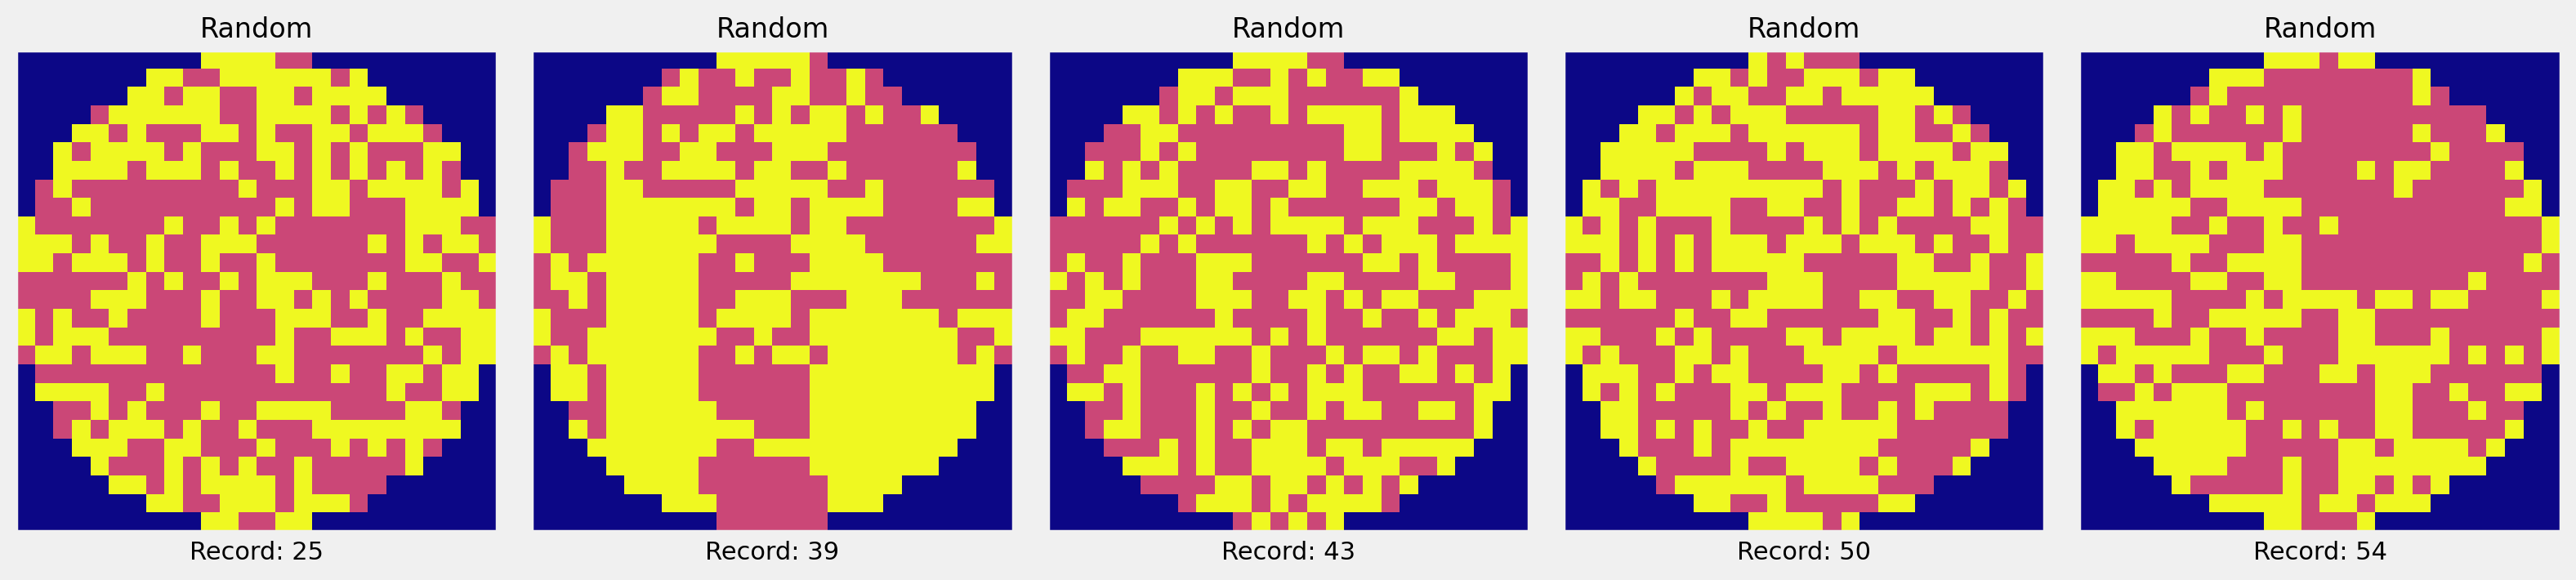

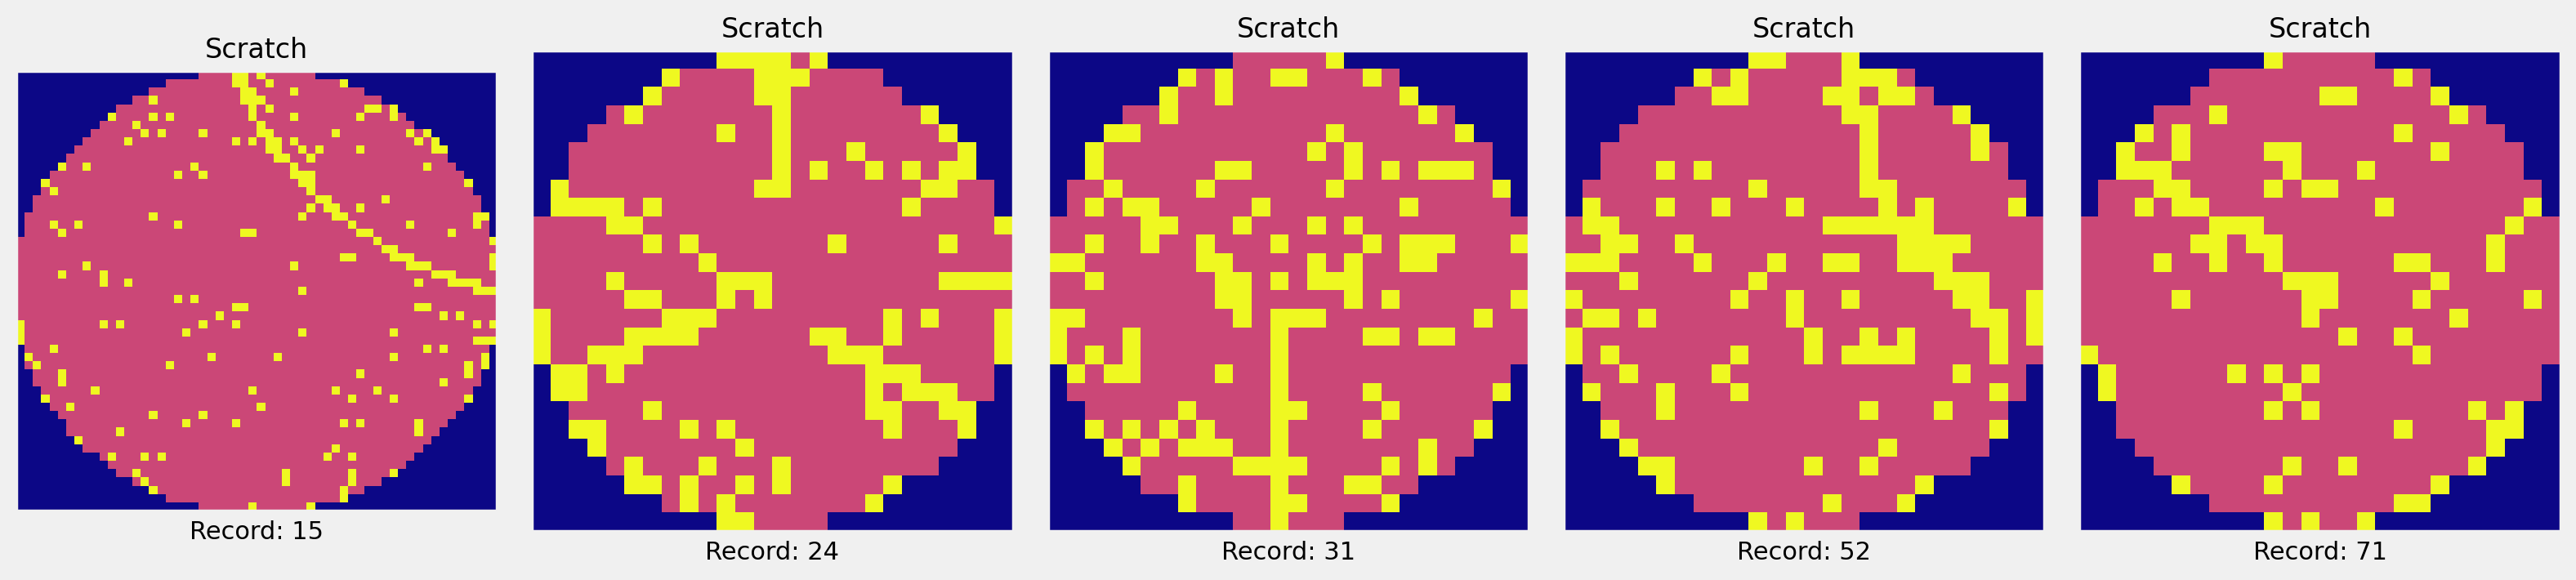

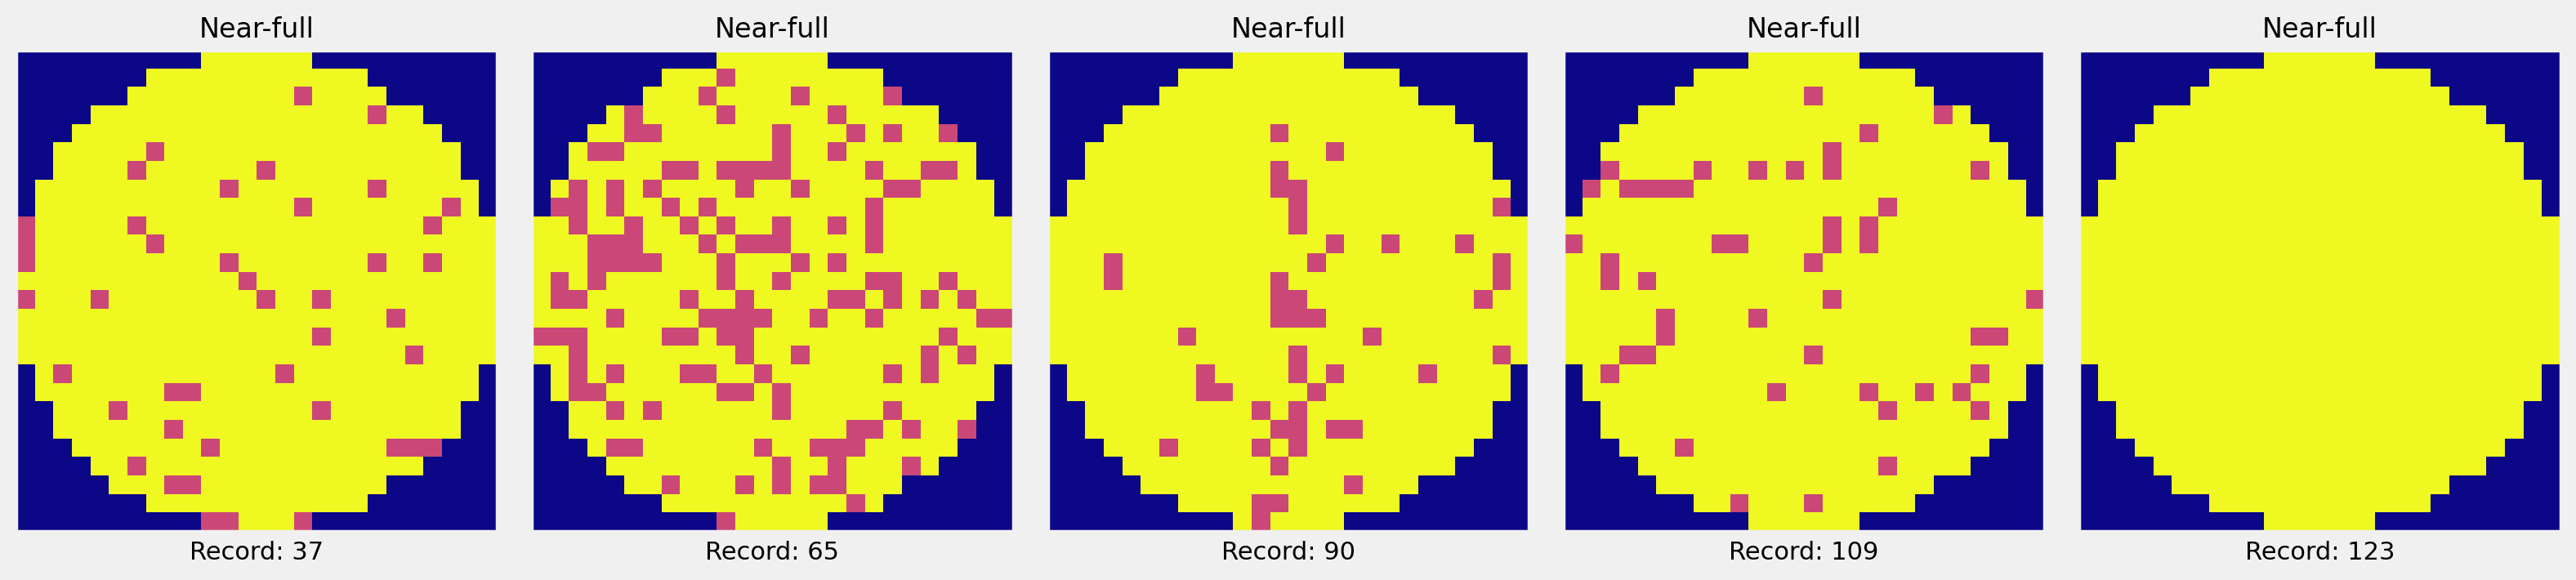

In [30]:
# Generate individual showcases per anomaly category
category_indices = range(8)
anomaly_categories = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Random', 'Scratch', 'Near-full']

for cat_idx in category_indices:
    fig, axes = plt.subplots(1, 5, figsize=(16,8))
    axes = axes.flatten()

    # CHANGE: Filter by defect_code instead of anomalyClass
    samples_subset = df_identified_faults[df_identified_faults['defect_code'] == cat_idx]

    if len(samples_subset) < 5:
        print(f"Skipping category {anomaly_categories[cat_idx]}: only {len(samples_subset)} samples")
        continue

    for i in range(5):
        axes[i].imshow(samples_subset.waferMap.iloc[i], cmap='plasma')  # CHANGE: waferMap
        axes[i].set_title(samples_subset.failureType_clean.iloc[i], fontsize=12)  # CHANGE: failureType_clean
        axes[i].set_xlabel(f'Record: {samples_subset.index[i]}', fontsize=11)
        axes[i].set_xticks([])
        axes[i].set_yticks([])

    plt.tight_layout()
    plt.show()

### Canonical Examples Across All Categories

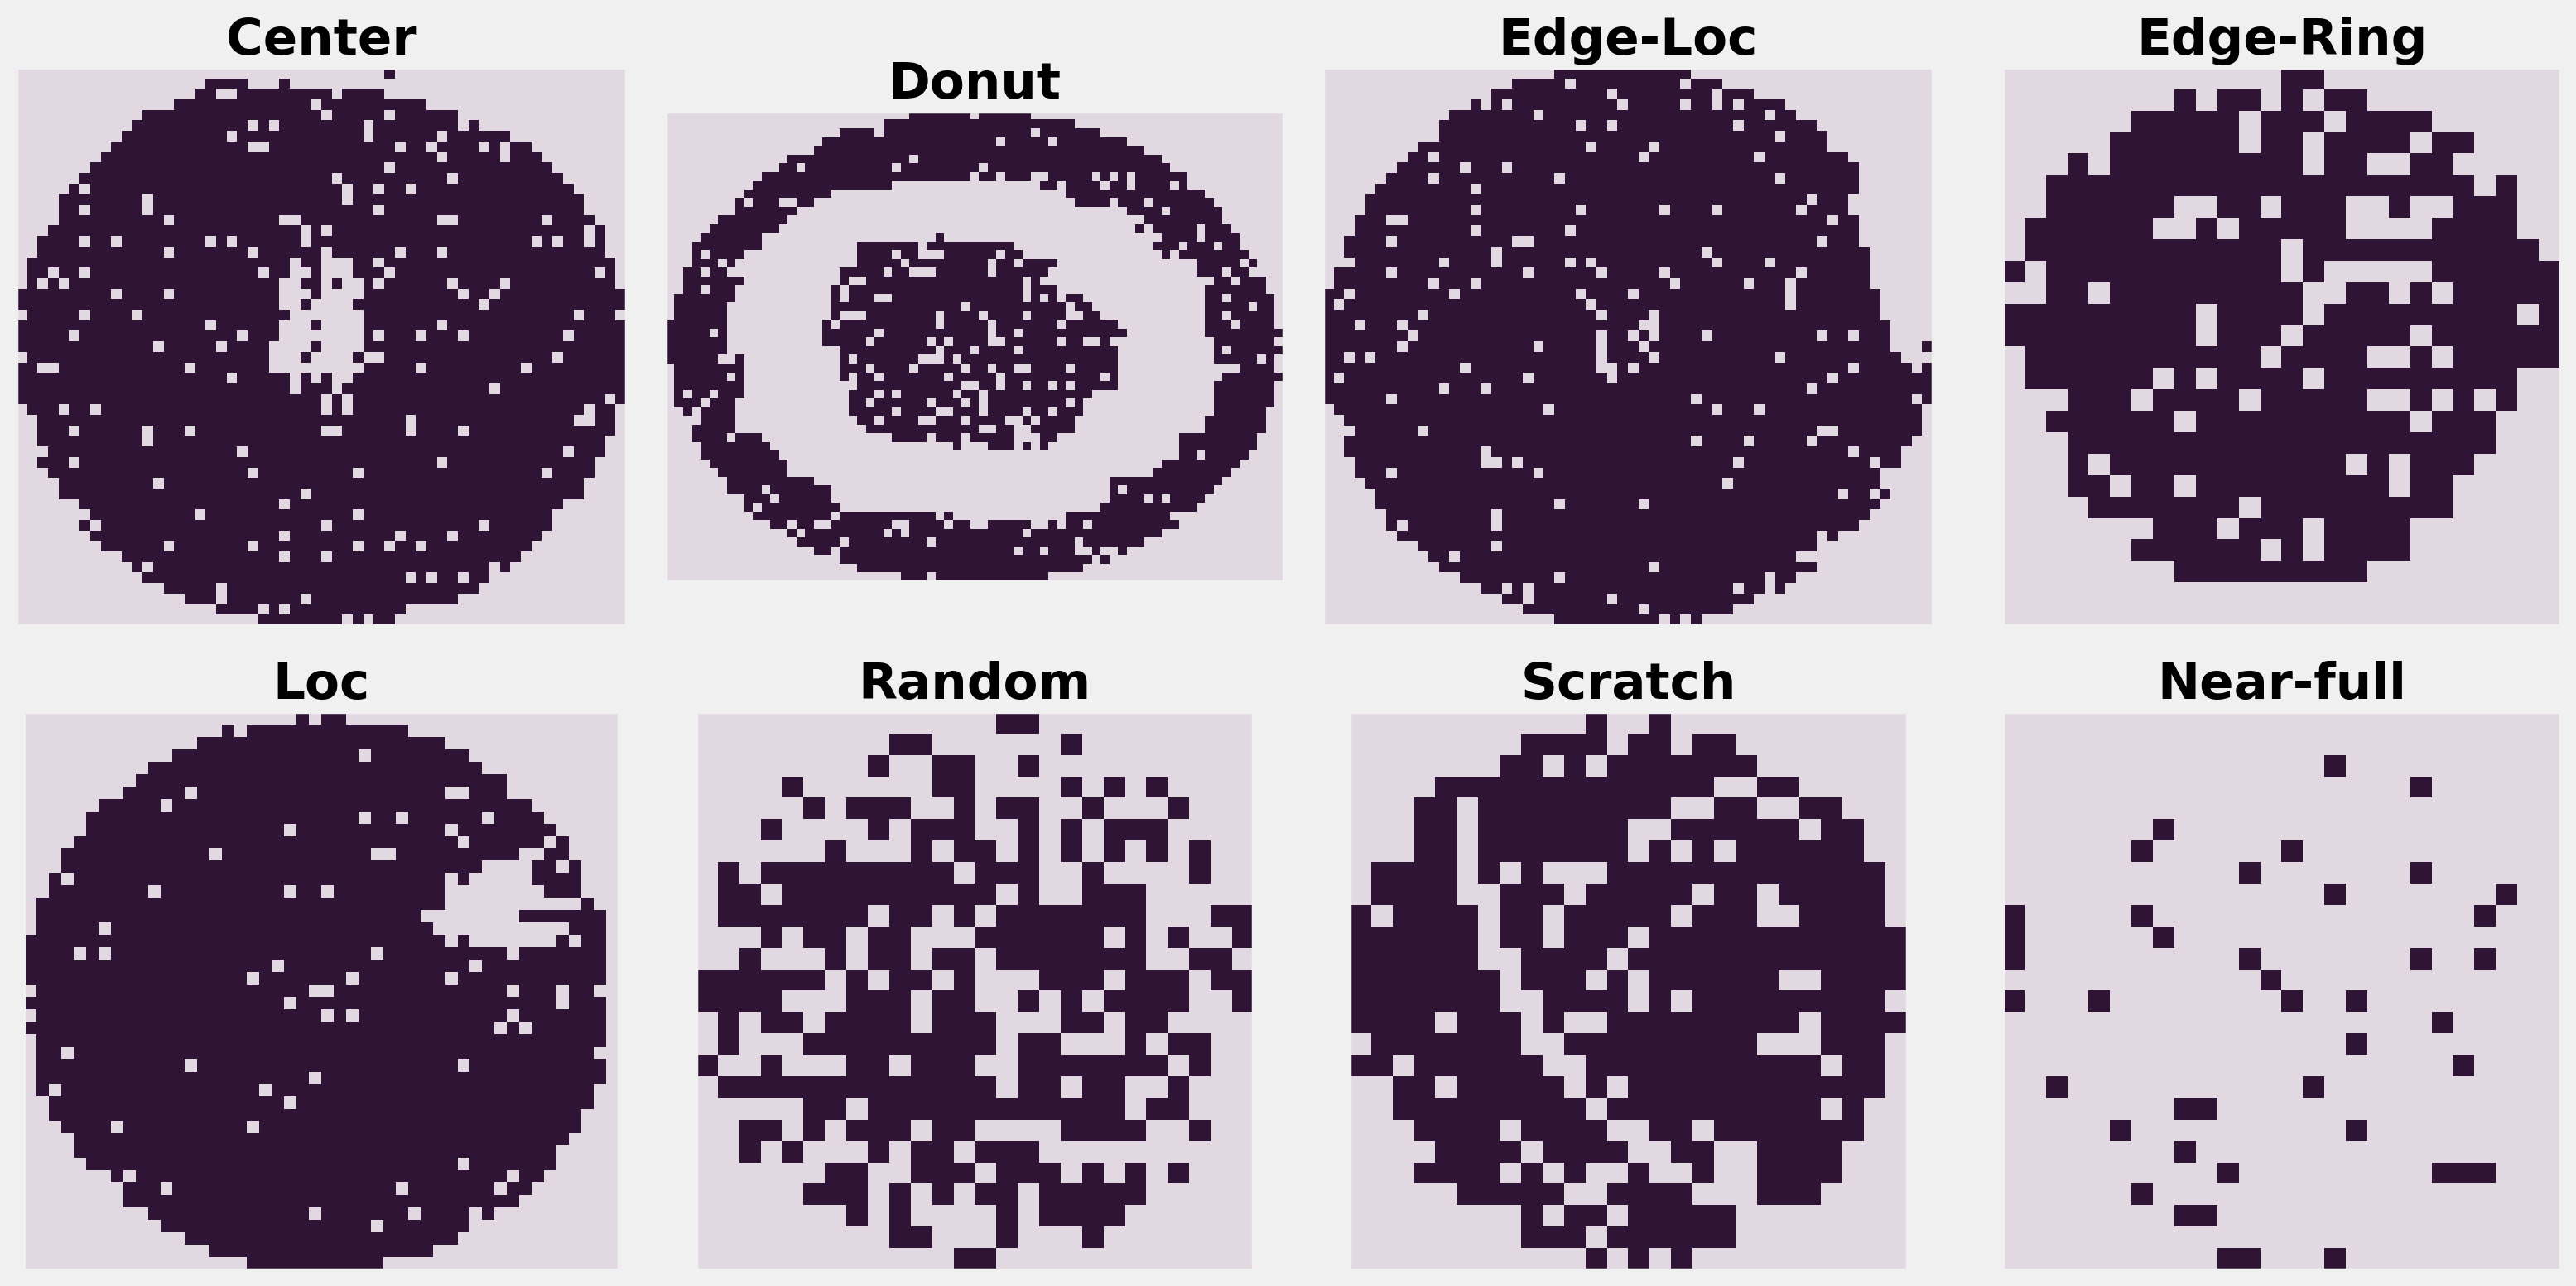

In [31]:
# Curated exemplars from each category
exemplar_indices = [9, 340, 3, 16, 0, 25, 84, 37]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, idx in enumerate(exemplar_indices):
    if idx < len(df_identified_faults):
        substrate_scan = df_identified_faults.waferMap.iloc[idx]  # CHANGE: waferMap and use .iloc
        axes[i].imshow(substrate_scan, cmap='twilight')
        axes[i].set_title(df_identified_faults.failureType_clean.iloc[idx], fontsize=22, weight='bold')  # CHANGE
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.tight_layout()
plt.show()

## Deep Convolutional Architecture Design

In [32]:
# Construct multi-block CNN for hierarchical feature extraction
neural_net = Sequential([
    InputLayer(input_shape=(224, 224, 3)),

    # Convolutional block A: Initial feature detection
    Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(16, (3, 3), padding='same', activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(),

    # Convolutional block B: Intermediate abstraction
    Conv2D(32, (3, 3), padding='same', activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(32, (3, 3), padding='same', activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(),

    # Convolutional block C: Advanced pattern recognition
    Conv2D(64, (3, 3), padding='same', activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), padding='same', activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(),

    # Convolutional block D: Deep semantic features
    Conv2D(128, (2, 2), padding='same', activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (2, 2), padding='same', activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(),

    # Convolutional block E: Regularization and compression
    SpatialDropout2D(0.2),
    MaxPooling2D(pool_size=(2, 2)),

    # Fully connected layers for classification
    Flatten(),
    Dense(512, activation='relu'),
    Dense(9, activation='softmax')
])

# Compile with categorical cross-entropy and Adam optimizer
neural_net.compile(optimizer=Adam(learning_rate=0.001),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

neural_net.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 222, 222, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 111, 111, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 111, 111, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 111, 111, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 111, 111, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 55, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 55, 55, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 55, 55, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 55, 55, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 55, 55, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 27, 27, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 27, 27, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 27, 27, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 27, 27, 128)    │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 27, 27, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 13, 13, 128)    │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 13, 13, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 13, 13, 128)    │             

 Total params: 2,536,985 (9.68 MB)

 Trainable params: 2,536,025 (9.67 MB)

 Non-trainable params: 960 (3.75 KB)

## Image Preprocessing Utilities

In [33]:
def one_hot_encoding(images, height, width):
    reshaped_images = np.zeros((len(images), height, width, 3))
    for n in range(len(images)):
        for h in range(height):
            for w in range(width):
                reshaped_images[n, h, w, images[n][h][w]] = 1
    return reshaped_images

def geometric_augmentation(images_series, sample_size=None):
    """Apply augmentation to image series (handles 2D grayscale)"""
    seq = iaa.Sequential([
        iaa.Fliplr(0.5),
        iaa.Affine(
            scale={"x": (0.8, 1.2), "y": (0.8, 1.2)},
            translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
            rotate=(-180, 180),
            shear=(-8, 8)
        ),
    ], random_order=True)

    # Convert Series to list if needed
    images_list = images_series.values if hasattr(images_series, 'values') else images_series

    if sample_size:
        indices = np.random.choice(len(images_list), sample_size, replace=True)
        images_list = [images_list[i] for i in indices]

    # Convert 2D grayscale images to 3D for imgaug compatibility
    images_3d = []
    for img in images_list:
        if len(img.shape) == 2:  # If 2D
            img_3d = np.stack([img, img, img], axis=-1)  # Replicate across 3 channels
        else:
            img_3d = img  # Already 3D
        images_3d.append(img_3d)

    images_array = np.array(images_3d)
    augmented_images = seq(images=images_array)

    return augmented_images


## Dataset Construction Pipeline

In [34]:
# Configuration parameters
num_categories = 9
target_resolution = (224, 224)
train_samples_per_category = 80
test_samples_per_category = 20

def assemble_dataset(source_df, samples_per_category, target_size, num_classes):
    # Construct training/validation tensors with augmentation and normalization
    feature_list, label_list = [], []

    for class_id in range(num_classes):
        # Use waferMap and defect_code
        category_samples = source_df[source_df['defect_code'] == class_id].sample(
            min(samples_per_category, len(source_df[source_df['defect_code'] == class_id])),
            replace=True
        ).waferMap

        # Resize to standardized dimensions
        resized_batch = category_samples.apply(lambda x: cv2.resize(x, dsize=target_size, interpolation=cv2.INTER_AREA))

        # Apply geometric transformations
        augmented_batch = np.array(geometric_augmentation(resized_batch))

        # Encode as one-hot tensors
        encoded_batch = one_hot_encoding(augmented_batch, target_size[0], target_size[1])
        del augmented_batch

        # Create one-hot label vectors
        class_labels = np.zeros((len(category_samples), num_classes))
        class_labels[:, class_id] = 1

        feature_list.extend(encoded_batch)
        label_list.extend(class_labels)

    return np.array(feature_list), np.array(label_list)
# Generate training and validation datasets
X_training, Y_training = assemble_dataset(df_all_labeled, train_samples_per_category, target_resolution, num_categories)
X_validation, Y_validation = assemble_dataset(df_all_labeled, test_samples_per_category, target_resolution, num_categories)

print(f"Training set shape: {X_training.shape}")
print(f"Validation set shape: {X_validation.shape}")

Training set shape: (720, 224, 224, 3)
Validation set shape: (180, 224, 224, 3)


## Model Training and Performance Monitoring

In [35]:
# Execute training loop
training_history = neural_net.fit(
    X_training, Y_training,
    validation_data=(X_validation, Y_validation),
    epochs=3,
    batch_size=100,
    verbose=1
)

Epoch 1/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 63s 7s/step - accuracy: 0.2201 - loss: 9.6371 - val_accuracy: 0.1111 - val_loss: 10.6068
Epoch 2/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 79s 7s/step - accuracy: 0.4558 - loss: 2.0752 - val_accuracy: 0.1167 - val_loss: 4.7309
Epoch 3/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 55s 7s/step - accuracy: 0.5887 - loss: 1.2355 - val_accuracy: 0.1167 - val_loss: 3.6639


### Accuracy Trajectory

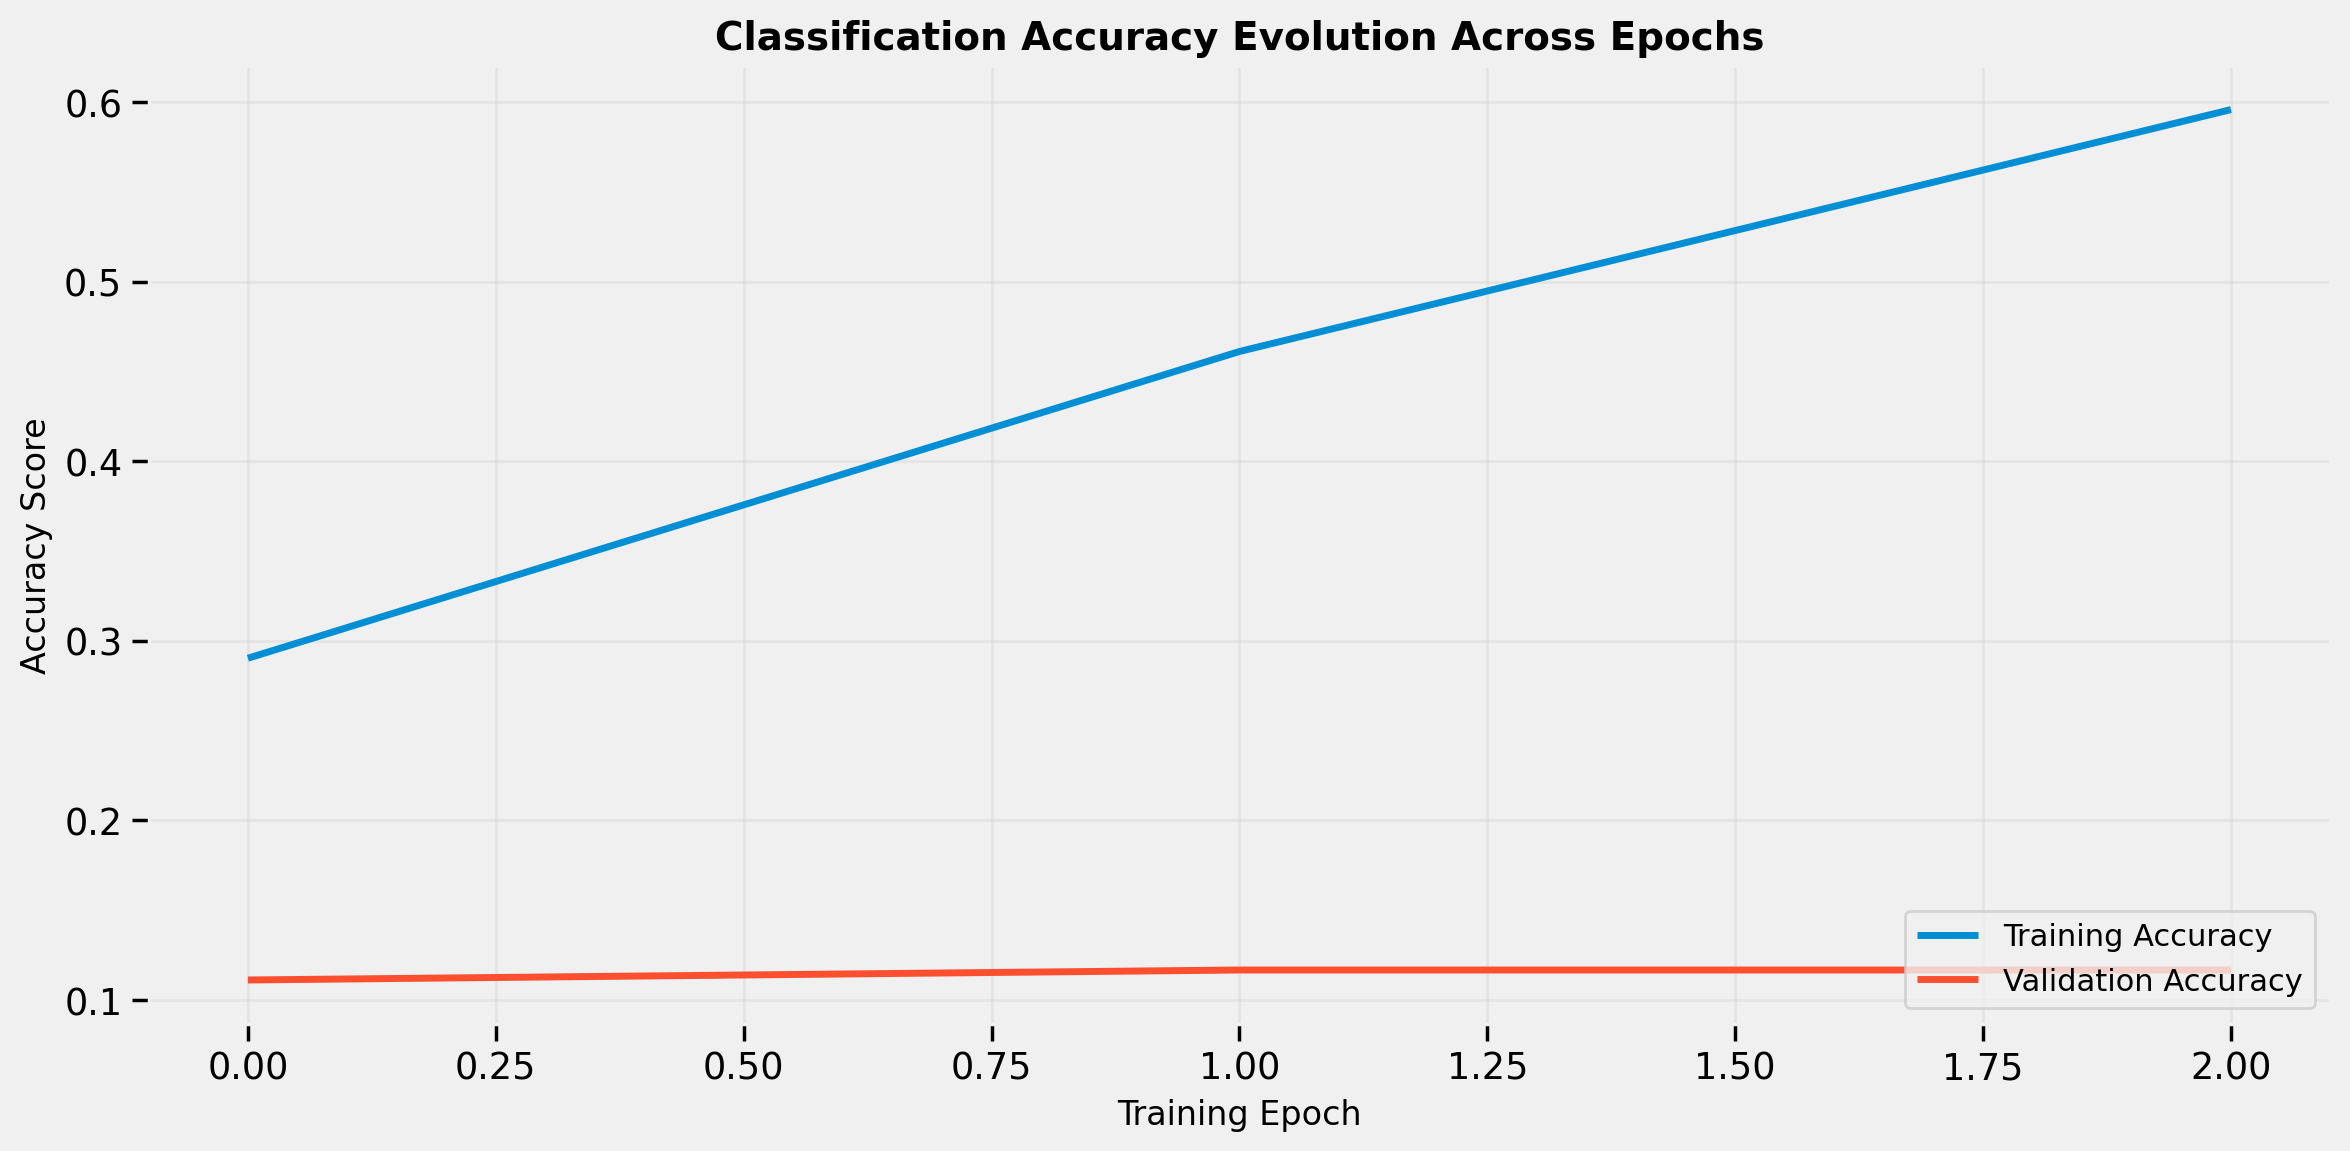

In [36]:
# Visualize learning curve
fig, acc_plot = plt.subplots(figsize=(12, 6))

acc_plot.plot(training_history.history['accuracy'],
              label='Training Accuracy', linewidth=2.5)
acc_plot.plot(training_history.history['val_accuracy'],
              label='Validation Accuracy', linewidth=2.5)

acc_plot.set_title('Classification Accuracy Evolution Across Epochs', fontsize=14, weight='bold')
acc_plot.set_xlabel('Training Epoch', fontsize=12)
acc_plot.set_ylabel('Accuracy Score', fontsize=12)
acc_plot.legend(loc='lower right', fontsize=11)
acc_plot.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Loss Trajectory

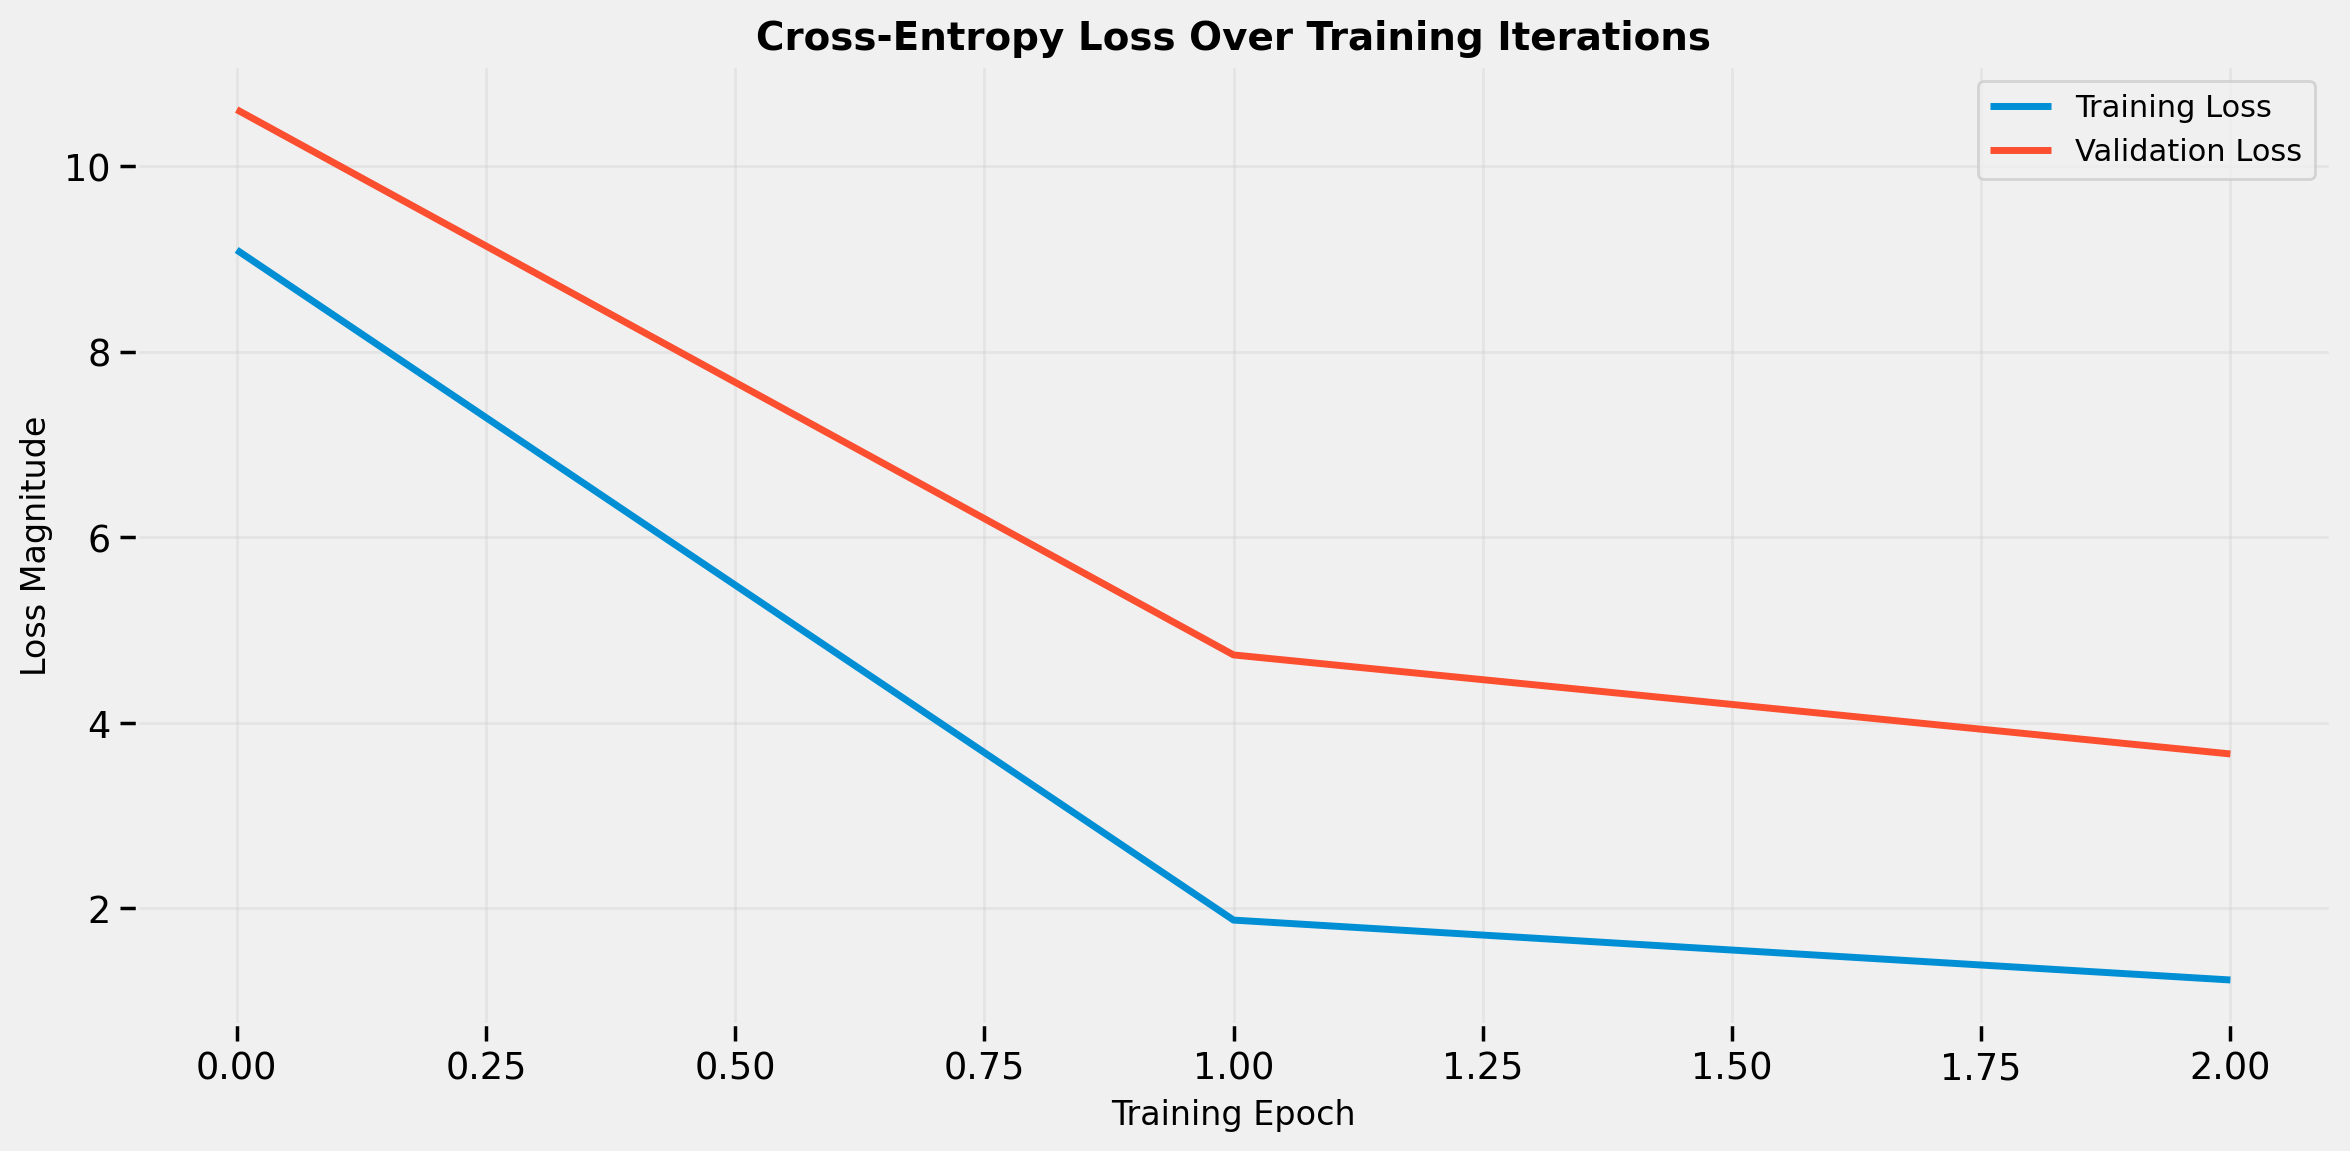

In [37]:
# Visualize loss curve
fig, loss_plot = plt.subplots(figsize=(12, 6))

loss_plot.plot(training_history.history['loss'],
               label='Training Loss', linewidth=2.5)
loss_plot.plot(training_history.history['val_loss'],
               label='Validation Loss', linewidth=2.5)

loss_plot.set_title('Cross-Entropy Loss Over Training Iterations', fontsize=14, weight='bold')
loss_plot.set_xlabel('Training Epoch', fontsize=12)
loss_plot.set_ylabel('Loss Magnitude', fontsize=12)
loss_plot.legend(loc='upper right', fontsize=11)
loss_plot.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Model Evaluation and Diagnostic Metrics

              precision    recall  f1-score   support

      Center       0.00      0.00      0.00        20
       Donut       0.00      0.00      0.00        20
    Edge-Loc       0.00      0.00      0.00        20
   Edge-Ring       0.50      0.05      0.09        20
         Loc       0.00      0.00      0.00        20
      Random       0.11      1.00      0.20        20
     Scratch       0.00      0.00      0.00        20
   Near-full       0.00      0.00      0.00        20
        None       0.00      0.00      0.00        20

    accuracy                           0.12       180
   macro avg       0.07      0.12      0.03       180
weighted avg       0.07      0.12      0.03       180



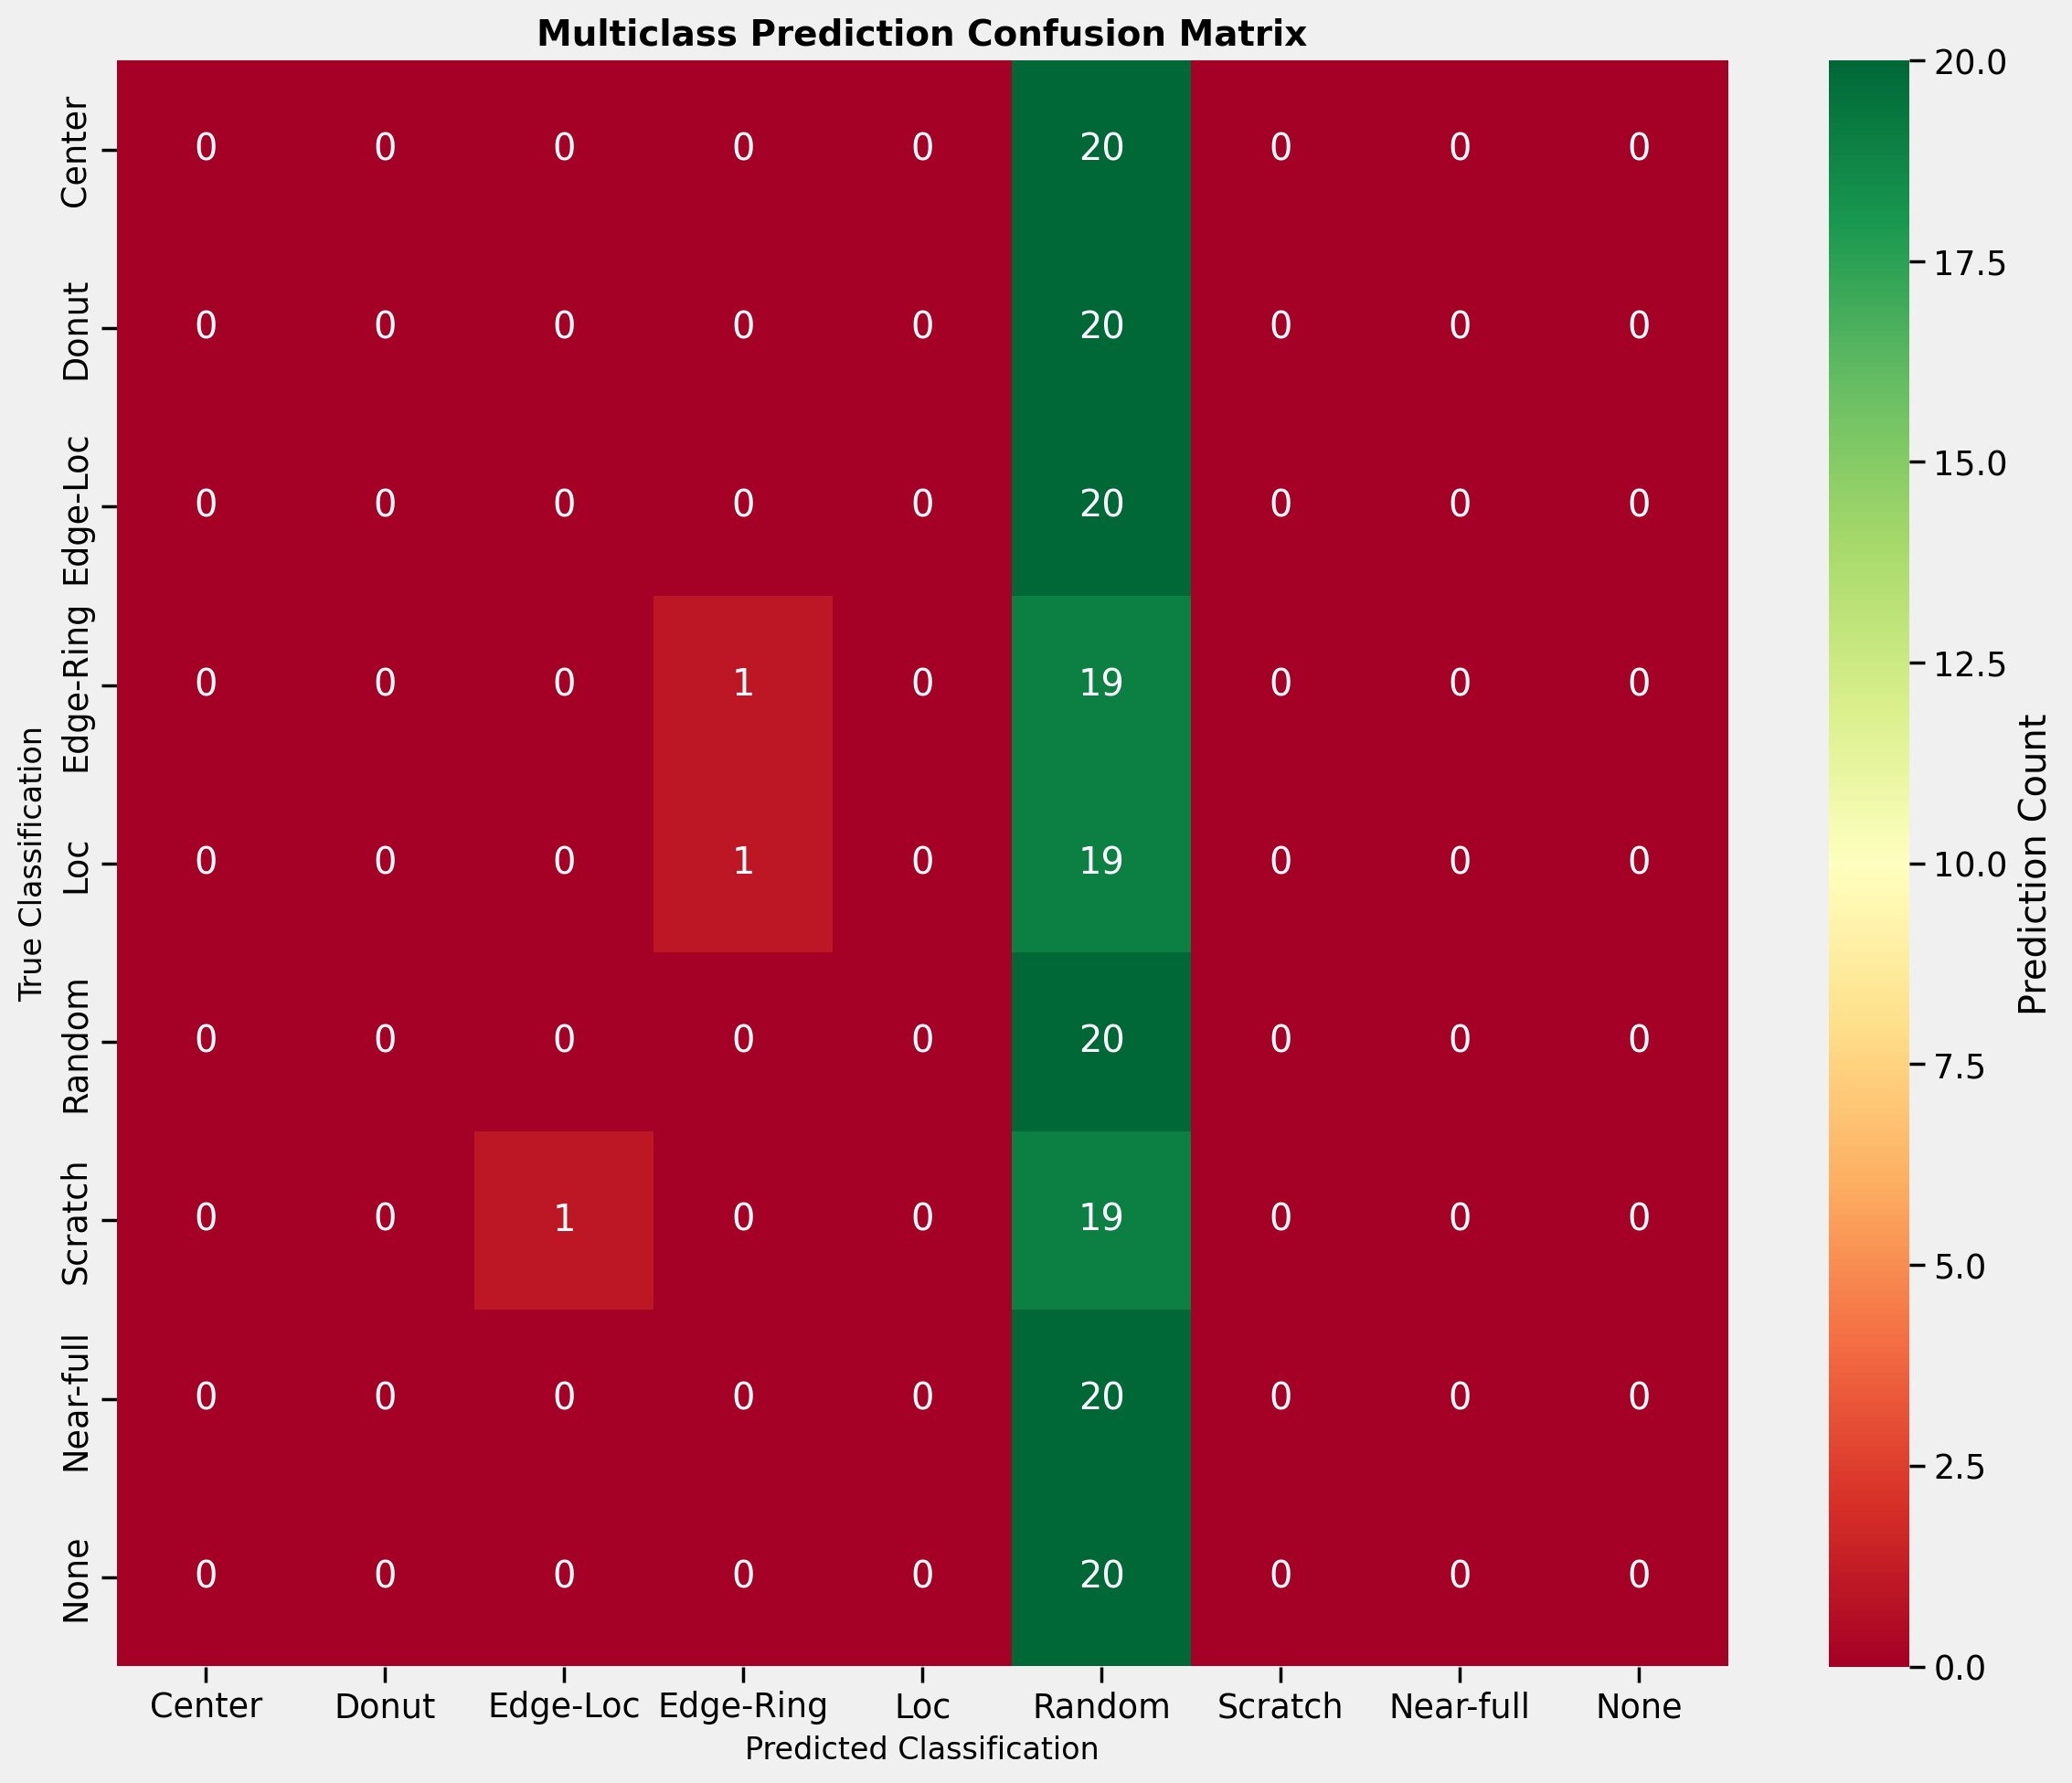

In [38]:
# Class label dictionary
class_mapping = {
    'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3,
    'Loc': 4, 'Random': 5, 'Scratch': 6, 'Near-full': 7, 'None': 8
}

# Generate predictions on validation set
prediction_probabilities = neural_net.predict(X_validation, verbose=0)  # Suppress progress output
predicted_labels = np.argmax(prediction_probabilities, axis=1)
ground_truth_labels = np.argmax(Y_validation, axis=1)

# Print detailed performance metrics
print(classification_report(ground_truth_labels, predicted_labels,
                          target_names=list(class_mapping.keys()),
                          zero_division=0))

# Compute confusion matrix
confusion_data = confusion_matrix(ground_truth_labels, predicted_labels)

# Heatmap visualization
fig, cm_plot = plt.subplots(figsize=(12, 10))
sb.heatmap(confusion_data, annot=True, fmt='d', cmap='RdYlGn',
           xticklabels=list(class_mapping.keys()),
           yticklabels=list(class_mapping.keys()),
           cbar_kws={'label': 'Prediction Count'})

cm_plot.set_title('Multiclass Prediction Confusion Matrix', fontsize=14, weight='bold')
cm_plot.set_xlabel('Predicted Classification', fontsize=12)
cm_plot.set_ylabel('True Classification', fontsize=12)

plt.tight_layout()
plt.show()